# Project Overview

HIV remains a significant public health concern in Africa, particularly in sub-Saharan regions. Despite advances in prevention and treatment, HIV is a lifelong condition that continues to affect millions. Tracking HIV data is essential for understanding infection trends, optimizing healthcare services, addressing stigma and inequality, and minimizing socio-economic impacts such as poverty and healthcare costs.

This project aims to analyze country-level HIV data from the World Health Organization (WHO) covering the period from 2000 to 2023. We will create visualizations to identify the countries that contribute to 75% of the global HIV burden, both globally and within each WHO region. Additionally, we will explore the relationship between HIV prevalence and multidimensional poverty indicators using World Bank data. Further, we will analyze under-five and neonatal mortality rates in East African Community (EAC) countries, using geospatial visualizations and trend analysis.

# Business Understanding

The primary objectives of this project are:

- **Identify Trends:** Highlight the countries and regions that contribute most significantly to the global HIV burden over time.
- **Resource Allocation:** Support governments and organizations in making informed decisions about resource distribution and policy development to reduce HIV transmission and improve quality of life.
- **Understand Socio-Economic Links:** Examine how multidimensional poverty factors (such as income, education, sanitation, and water access) are associated with HIV prevalence.
- **Child Mortality Analysis:** Visualize and analyze under-five and neonatal mortality rates across East African countries to guide targeted health interventions.
- **Support Public Health Strategy:** Provide insights that can help improve healthcare systems, social support mechanisms, and development programs, particularly in heavily impacted regions.

# Data Description

## 1. HIV Data
- **Source:** World Health Organization (WHO) Global Observatory
- **Period Covered:** 2000 - 2023
- **Key Columns:**
  - `IndicatorCode`: Code for the indicator
  - `Indicator`: Name of the indicator
  - `ValueType`: Type of value reported
  - `ParentLocationCode`: WHO region code
  - `ParentLocation`: WHO region name
  - `Location type`: Level of location (country, region, etc.)
  - `SpatialDimValueCode`: Country code
  - `Location`: Country name
  - `Period type`: Type of period (yearly)
  - `Period`: Year
  - `Value`: Number of people living with HIV

## 2. Multidimensional Poverty Data
- **Source:** World Bank
- **Description:** Data includes poverty headcount ratios based on multiple indicators like:
  - Income
  - Educational attainment
  - School enrollment
  - Electricity access
  - Sanitation
  - Drinking water
  
This dataset will be merged with the HIV data to explore the relationship between poverty and HIV prevalence.

## 3. Under-Five Mortality Rate Data and Neonatal Mortality Rate Data
- **Source:** United Nations Inter-agency Group for Child Mortality Estimation
- **Geographic Focus:** African countries, especially East African Community (EAC) members
- **Key Columns:**
  - `REF_AREA`: Country code
  - `Geographic area`: Country name
  - `INDICATOR`: Mortality indicator
  - `TIME_PERIOD`: Year
  - `OBS_VALUE`: Observed mortality value

## Additional Notes
- Spatial analysis will involve using shapefiles from [GADM](https://gadm.org/) to create geospatial maps.
- Random effects such as country and year will be accounted for during the statistical modeling phase when analyzing relationships between variables.


In [1]:
# Imports

import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter
import numpy as np
import seaborn as sns
import matplotlib.gridspec as gridspec
import matplotlib.cm as cm
from matplotlib.colors import LinearSegmentedColormap
from matplotlib.patches import Patch
from statsmodels.regression.mixed_linear_model import MixedLM
import geopandas as gpd
from scipy import stats
import statsmodels.formula.api as smf

# Set the style for more attractive visualizations
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_context("talk")

%matplotlib inline

import warnings
warnings.filterwarnings('ignore')

# PROJECT 1

In [2]:
# Load HIV Dataset and create HIV Dataframe

hiv_df = pd.read_csv("HIV data 2000-2023.csv", encoding='ISO-8859-1')

In [3]:
# Preview first 5 rows of the HIV dataframe

hiv_df.head()

,IndicatorCode,Indicator,ValueType,ParentLocationCode,ParentLocation,Location type,SpatialDimValueCode,Location,Period type,Period,Value
0,HIV_0000000001,Estimated number of people (all ages) living w...,numeric,AFR,Africa,Country,AGO,Angola,Year,2023,320 000 [280 000 - 380 000]
1,HIV_0000000001,Estimated number of people (all ages) living w...,numeric,AFR,Africa,Country,AGO,Angola,Year,2022,320 000 [280 000 - 380 000]
2,HIV_0000000001,Estimated number of people (all ages) living w...,numeric,AFR,Africa,Country,AGO,Angola,Year,2021,320 000 [280 000 - 380 000]
3,HIV_0000000001,Estimated number of people (all ages) living w...,numeric,AFR,Africa,Country,AGO,Angola,Year,2020,320 000 [280 000 - 370 000]
4,HIV_0000000001,Estimated number of people (all ages) living w...,numeric,AFR,Africa,Country,AGO,Angola,Year,2015,300 000 [260 000 - 350 000]


In [4]:
# Look at the information in the hiv_df

hiv_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1552 entries, 0 to 1551
Data columns (total 11 columns):
 #   Column               Non-Null Count  Dtype 
---  ------               --------------  ----- 
 0   IndicatorCode        1552 non-null   object
 1   Indicator            1552 non-null   object
 2   ValueType            1552 non-null   object
 3   ParentLocationCode   1552 non-null   object
 4   ParentLocation       1552 non-null   object
 5   Location type        1552 non-null   object
 6   SpatialDimValueCode  1552 non-null   object
 7   Location             1552 non-null   object
 8   Period type          1552 non-null   object
 9   Period               1552 non-null   int64 
 10  Value                1552 non-null   object
dtypes: int64(1), object(10)
memory usage: 133.5+ KB


In [5]:
# Checking for missing or null values in the hiv dataframe

hiv_df.isna().sum()

IndicatorCode          0
Indicator              0
ValueType              0
ParentLocationCode     0
ParentLocation         0
Location type          0
SpatialDimValueCode    0
Location               0
Period type            0
Period                 0
Value                  0
dtype: int64

## **Data Cleaning**

In [6]:
# Extract Value i.e., number of people living with hiv and assign to NumericValue column

hiv_df["NumericValue"] = hiv_df["Value"].str.extract(r'([\d\s]+)')

hiv_df[["Value","NumericValue"]].head()

,Value,NumericValue
0,320 000 [280 000 - 380 000],320 000
1,320 000 [280 000 - 380 000],320 000
2,320 000 [280 000 - 380 000],320 000
3,320 000 [280 000 - 370 000],320 000
4,300 000 [260 000 - 350 000],300 000


- At this point I was unable to convert the newly created NumericValue column datatype to numeric, as not all values in the Value column followed this format (300 000 [260 000 - 350 000]) and thus could not be converted to numeric. So I proceeded to looking into these non numeric values.

In [7]:
# Find rows where the extracted value is either NaN or an empty string

problem_rows = hiv_df[hiv_df["NumericValue"].isna() | (hiv_df["NumericValue"].str.strip() == '')]

# Display the values in `Value` column and count of those values 

problem_rows["Value"].value_counts()

Value
No data    394
Name: count, dtype: int64

In [8]:
# Display The Problem rows in Value column against the Extracted NumericValue column to see how they appear

problem_rows[["Value","NumericValue"]].head()

,Value,NumericValue
40,No data,
41,No data,
42,No data,
43,No data,
44,No data,


- So where data in Value column is "No data" an empty string was being returned in the numeric column. So I will proceed to drop all rows where The data in the Value column i.e., number of people living with HIV is recorded as "No Data"

In [9]:
# Drop rows where the Value is "No Data"

hiv_df.drop(
    hiv_df[(hiv_df["Value"].str.strip().str.lower() == "no data")].index,
    inplace=True
)

In [10]:
# Confirming the rows with "No Data" in the Value column have been dropped

len(hiv_df[hiv_df["Value"] == "No Data"])

0

In [11]:
# Convert NumericValue column data to integers

hiv_df["NumericValue"] = hiv_df["NumericValue"].str.replace(' ', '', regex=False).astype(int)

In [12]:
hiv_df[["Value","NumericValue"]].head()

,Value,NumericValue
0,320 000 [280 000 - 380 000],320000
1,320 000 [280 000 - 380 000],320000
2,320 000 [280 000 - 380 000],320000
3,320 000 [280 000 - 370 000],320000
4,300 000 [260 000 - 350 000],300000


In [13]:
# Confirming the datatype conversion from string to integer

hiv_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1158 entries, 0 to 1535
Data columns (total 12 columns):
 #   Column               Non-Null Count  Dtype 
---  ------               --------------  ----- 
 0   IndicatorCode        1158 non-null   object
 1   Indicator            1158 non-null   object
 2   ValueType            1158 non-null   object
 3   ParentLocationCode   1158 non-null   object
 4   ParentLocation       1158 non-null   object
 5   Location type        1158 non-null   object
 6   SpatialDimValueCode  1158 non-null   object
 7   Location             1158 non-null   object
 8   Period type          1158 non-null   object
 9   Period               1158 non-null   int64 
 10  Value                1158 non-null   object
 11  NumericValue         1158 non-null   int64 
dtypes: int64(2), object(10)
memory usage: 117.6+ KB


In [14]:
hiv_df.head()

,IndicatorCode,Indicator,ValueType,ParentLocationCode,ParentLocation,Location type,SpatialDimValueCode,Location,Period type,Period,Value,NumericValue
0,HIV_0000000001,Estimated number of people (all ages) living w...,numeric,AFR,Africa,Country,AGO,Angola,Year,2023,320 000 [280 000 - 380 000],320000
1,HIV_0000000001,Estimated number of people (all ages) living w...,numeric,AFR,Africa,Country,AGO,Angola,Year,2022,320 000 [280 000 - 380 000],320000
2,HIV_0000000001,Estimated number of people (all ages) living w...,numeric,AFR,Africa,Country,AGO,Angola,Year,2021,320 000 [280 000 - 380 000],320000
3,HIV_0000000001,Estimated number of people (all ages) living w...,numeric,AFR,Africa,Country,AGO,Angola,Year,2020,320 000 [280 000 - 370 000],320000
4,HIV_0000000001,Estimated number of people (all ages) living w...,numeric,AFR,Africa,Country,AGO,Angola,Year,2015,300 000 [260 000 - 350 000],300000


In [15]:
# I want to check if apart from Year value in the Period Type there's another value

hiv_df["Period type"].value_counts()

Period type
Year    1158
Name: count, dtype: int64

- So the only Period Type value is Year and as such the data contained in the Period Column represent Year Value

## **Exploratory Data Analysis**

### **QUESTION 1.1: Create a visualization that shows the trend of HIV cases in the countries that contribute to 75% of the global burden**

- I'll start by summing up the total number of people living with HIV Globally per year which will eventually help in calculating citizens of countries that contribute to 75% of the global burden

In [16]:
# Grouping the Data by Year("Period") and summing the Number of people living with HIV

yearly_totals = hiv_df.groupby("Period")["NumericValue"].sum().reset_index()

In [17]:
# Renaming the column to 'GlobalTotal' to make it clear it's the total HIV cases globally in that year
# This will also help not to cause a name conflict when merging later to the main hiv_df dataframe.

yearly_totals.rename(columns={"NumericValue": "GlobalTotal"}, inplace=True)

In [18]:
# Merging global totals back into the main DataFrame based on Period. 
# This will help tell me how much each country contributed to the global total that year.

hiv_merged = pd.merge(hiv_df, yearly_totals, on='Period')

In [19]:
# Examining the merged dataframe

hiv_merged.head()

,IndicatorCode,Indicator,ValueType,ParentLocationCode,ParentLocation,Location type,SpatialDimValueCode,Location,Period type,Period,Value,NumericValue,GlobalTotal
0,HIV_0000000001,Estimated number of people (all ages) living w...,numeric,AFR,Africa,Country,AGO,Angola,Year,2023,320 000 [280 000 - 380 000],320000,33933990
1,HIV_0000000001,Estimated number of people (all ages) living w...,numeric,AFR,Africa,Country,AGO,Angola,Year,2022,320 000 [280 000 - 380 000],320000,31198310
2,HIV_0000000001,Estimated number of people (all ages) living w...,numeric,AFR,Africa,Country,AGO,Angola,Year,2021,320 000 [280 000 - 380 000],320000,31314230
3,HIV_0000000001,Estimated number of people (all ages) living w...,numeric,AFR,Africa,Country,AGO,Angola,Year,2020,320 000 [280 000 - 370 000],320000,31016150
4,HIV_0000000001,Estimated number of people (all ages) living w...,numeric,AFR,Africa,Country,AGO,Angola,Year,2015,300 000 [260 000 - 350 000],300000,28925850


- I will proceed to calculate the Percentage contribution of each country per year

In [20]:
# For each country per year, calculates its percentage contribution to global cases.

hiv_merged["PercentOfGlobalTotal"] = ((hiv_merged["NumericValue"] / hiv_merged["GlobalTotal"]) * 100)

In [21]:
hiv_merged.head()

,IndicatorCode,Indicator,ValueType,ParentLocationCode,ParentLocation,Location type,SpatialDimValueCode,Location,Period type,Period,Value,NumericValue,GlobalTotal,PercentOfGlobalTotal
0,HIV_0000000001,Estimated number of people (all ages) living w...,numeric,AFR,Africa,Country,AGO,Angola,Year,2023,320 000 [280 000 - 380 000],320000,33933990,0.943007
1,HIV_0000000001,Estimated number of people (all ages) living w...,numeric,AFR,Africa,Country,AGO,Angola,Year,2022,320 000 [280 000 - 380 000],320000,31198310,1.025697
2,HIV_0000000001,Estimated number of people (all ages) living w...,numeric,AFR,Africa,Country,AGO,Angola,Year,2021,320 000 [280 000 - 380 000],320000,31314230,1.021900
3,HIV_0000000001,Estimated number of people (all ages) living w...,numeric,AFR,Africa,Country,AGO,Angola,Year,2020,320 000 [280 000 - 370 000],320000,31016150,1.031721
4,HIV_0000000001,Estimated number of people (all ages) living w...,numeric,AFR,Africa,Country,AGO,Angola,Year,2015,300 000 [260 000 - 350 000],300000,28925850,1.037135


- I will now create a function to identify countries contributing to 75% of global burden

In [22]:
# Function to identify countries contributing to 75% of global burden

def get_top_burden_countries(df, threshold=0.75):

    # Group by countrycode and country then sum the total HIV cases and sort them in descending order
    country_totals = (
        df.groupby(["SpatialDimValueCode", "Location"])["NumericValue"]
        .sum()
        .sort_values(ascending=False)
    )

    # Prepare result DataFrame
    country_totals_df = country_totals.reset_index()
    country_totals_df.rename(columns={"SpatialDimValueCode": "LocationCode"}, inplace=True)

    # Compute percentages
    global_total = country_totals_df["NumericValue"].sum()
    country_totals_df["Percentage"] = country_totals_df["NumericValue"] / global_total
    country_totals_df["CumulativePercentage"] = country_totals_df["Percentage"].cumsum()

    # Select top contributors that make up 75% of total global burden
    top_countries_df = country_totals_df[country_totals_df["CumulativePercentage"] <= threshold]

    # Ensure threshold is crossed
    if not top_countries_df.empty and top_countries_df["CumulativePercentage"].iloc[-1] < threshold:
        next_country = country_totals_df.iloc[len(top_countries_df)]
        top_countries_df = pd.concat([top_countries_df, next_country.to_frame().T], ignore_index=True)

    return top_countries_df

In [23]:
# Get the top 75% countries contributing to the global HIV burden from our hiv_merged dataframe

top_countries_df = get_top_burden_countries(hiv_merged)

In [24]:
# Examining the top 75% countries contributing to the global burden

top_countries_df

,LocationCode,Location,NumericValue,Percentage,CumulativePercentage
0,ZAF,South Africa,51400000,0.226139,0.226139
1,MOZ,Mozambique,15150000,0.066654,0.292793
2,NGA,Nigeria,15000000,0.065994,0.358787
3,KEN,Kenya,12000000,0.052795,0.411582
4,TZA,United Republic of Tanzania,11600000,0.051035,0.462617
5,ZWE,Zimbabwe,10900000,0.047956,0.510573
6,UGA,Uganda,10500000,0.046196,0.556769
7,ZMB,Zambia,8890000,0.039112,0.595881
8,MWI,Malawi,7760000,0.034141,0.630022
9,BRA,Brazil,6070000,0.026706,0.656727


In [25]:
# Define number formatter to show values in millions or thousands

def format_number(x, _):
    if x >= 1_000_000:
        return f'{x / 1_000_000:.1f}M'
    elif x >= 1_000:
        return f'{x / 1_000:.0f}K'
    else:
        return str(int(x))

In [26]:
# Get top countries' location codes from the top_75_global DataFrame
top_country_codes = top_countries_df['LocationCode'].tolist()

# Filtering the main HIV dataset to only include these top countries
top_countries_data = hiv_merged[hiv_merged['SpatialDimValueCode'].isin(top_country_codes)]

In [27]:
top_countries_data

,IndicatorCode,Indicator,ValueType,ParentLocationCode,ParentLocation,Location type,SpatialDimValueCode,Location,Period type,Period,Value,NumericValue,GlobalTotal,PercentOfGlobalTotal
40,HIV_0000000001,Estimated number of people (all ages) living w...,numeric,AFR,Africa,Country,CIV,Cote d'Ivoire,Year,2023,420 000 [370 000 - 480 000],420000,33933990,1.237697
41,HIV_0000000001,Estimated number of people (all ages) living w...,numeric,AFR,Africa,Country,CIV,Cote d'Ivoire,Year,2022,430 000 [380 000 - 490 000],430000,31198310,1.378280
42,HIV_0000000001,Estimated number of people (all ages) living w...,numeric,AFR,Africa,Country,CIV,Cote d'Ivoire,Year,2021,430 000 [390 000 - 490 000],430000,31314230,1.373178
43,HIV_0000000001,Estimated number of people (all ages) living w...,numeric,AFR,Africa,Country,CIV,Cote d'Ivoire,Year,2020,440 000 [390 000 - 490 000],440000,31016150,1.418616
44,HIV_0000000001,Estimated number of people (all ages) living w...,numeric,AFR,Africa,Country,CIV,Cote d'Ivoire,Year,2015,460 000 [420 000 - 510 000],460000,28925850,1.590273
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1057,HIV_0000000001,Estimated number of people (all ages) living w...,numeric,SEAR,South-East Asia,Country,THA,Thailand,Year,2020,590 000 [530 000 - 680 000],590000,31016150,1.902235
1058,HIV_0000000001,Estimated number of people (all ages) living w...,numeric,SEAR,South-East Asia,Country,THA,Thailand,Year,2015,640 000 [580 000 - 730 000],640000,28925850,2.212554
1059,HIV_0000000001,Estimated number of people (all ages) living w...,numeric,SEAR,South-East Asia,Country,THA,Thailand,Year,2010,720 000 [630 000 - 790 000],720000,26058620,2.763001
1060,HIV_0000000001,Estimated number of people (all ages) living w...,numeric,SEAR,South-East Asia,Country,THA,Thailand,Year,2005,810 000 [720 000 - 910 000],810000,23492620,3.447891


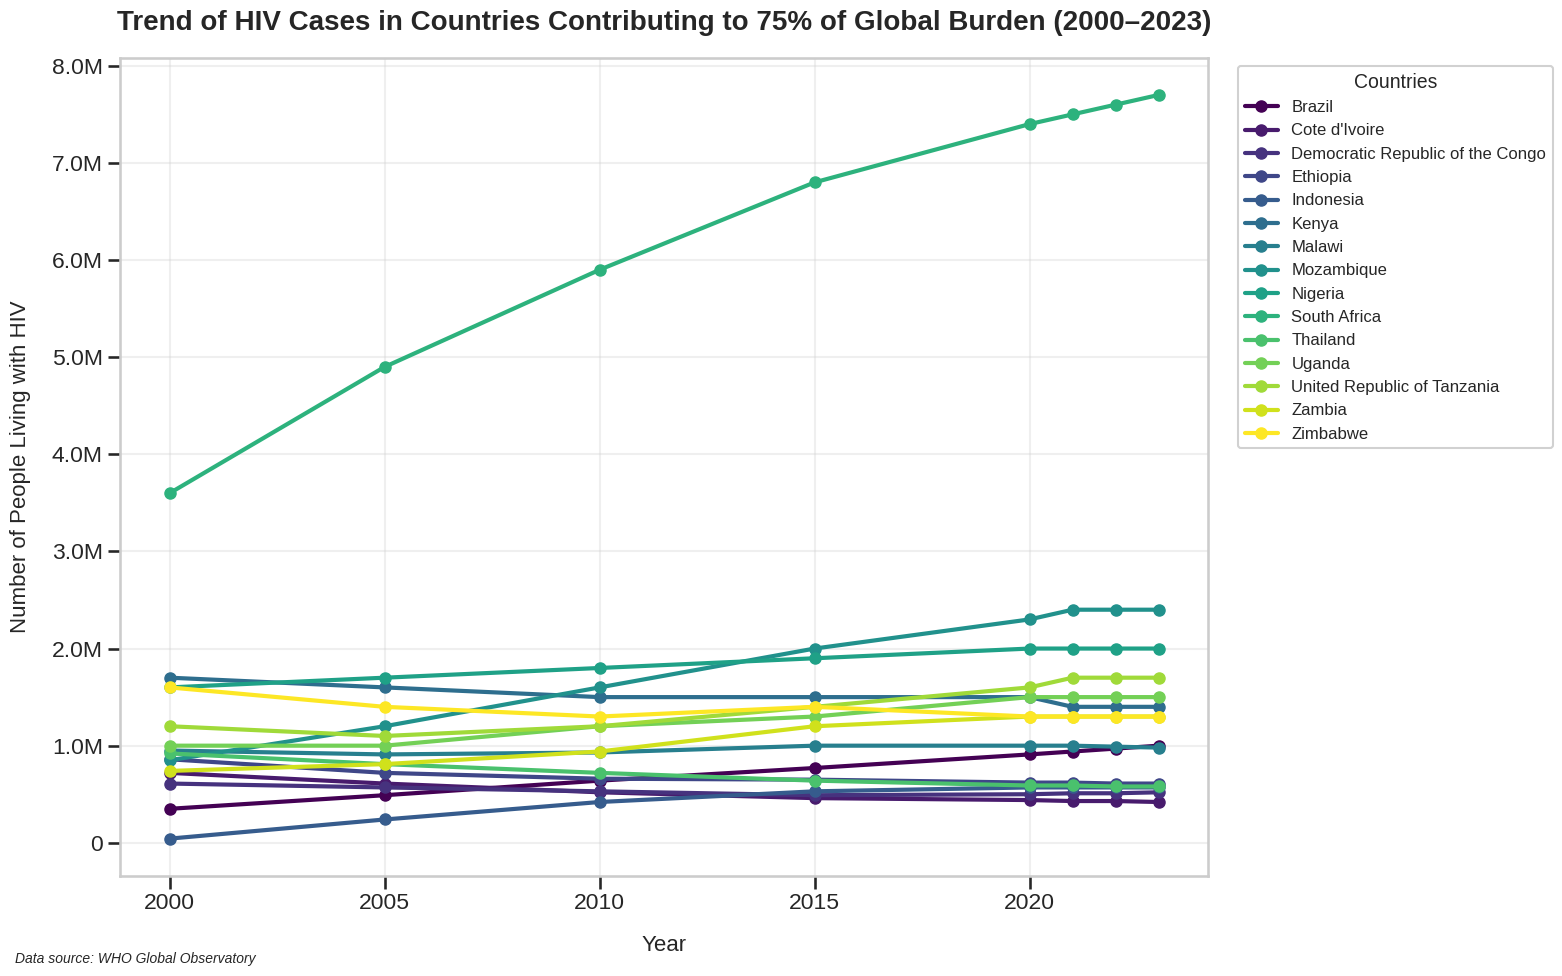

In [28]:
# Create a pivot table where each country is a column and years are rows
timeline_data = top_countries_data.pivot_table(
    index='Period',
    columns='Location',
    values='NumericValue',
    aggfunc='sum'  # or 'sum' if multiple entries per year exist
)

# Setup the plot
fig, ax = plt.subplots(figsize=(16, 10))

# Generate a colormap with enough distinct colors for the countries
colors = plt.cm.viridis(np.linspace(0, 1, len(timeline_data.columns)))

# Plotting the data
for i, country in enumerate(timeline_data.columns):
    ax.plot(
        timeline_data.index, 
        timeline_data[country],
        label=country,
        color=colors[i],
        linewidth=3,
        marker='o',
        markersize=8
    )

# Format the axes and add titles
ax.set_title('Trend of HIV Cases in Countries Contributing to 75% of Global Burden (2000–2023)', 
             fontsize=20, fontweight='bold', pad=20)
ax.set_xlabel('Year', fontsize=16, labelpad=15)
ax.set_ylabel('Number of People Living with HIV', fontsize=16, labelpad=15)
ax.yaxis.set_major_formatter(FuncFormatter(format_number))

# Add a subtle grid for readability
ax.grid(True, alpha=0.3)

# Add a legend outside the plot
legend = ax.legend(
    title="Countries", 
    title_fontsize=14, 
    fontsize=12,
    bbox_to_anchor=(1.02, 1), 
    loc='upper left', 
    frameon=True
)
legend.get_frame().set_alpha(0.9)

# Add a text annotation about data source
plt.figtext(0.02, 0.02, 'Data source: WHO Global Observatory', fontsize=10, style='italic')

# Layout adjustment and display the plot
plt.tight_layout()
plt.show();

In [29]:
# Sort the top_countries_df by Percentage in descending order
top_countries_df = top_countries_df.sort_values(by='Percentage', ascending=False).reset_index(drop=True)

# Header for the output
print("Countries contributing to 75% of global HIV burden (based on 2000-2023 data):")

# Loop through and print each country with its contribution
for i, row in top_countries_df.iterrows():
    country = row['Location']
    percentage = row['Percentage'] * 100  # Convert to percentage
    print(f"{i+1}. {country}: {percentage:.2f}%")


Countries contributing to 75% of global HIV burden (based on 2000-2023 data):
1. South Africa: 22.61%
2. Mozambique: 6.67%
3. Nigeria: 6.60%
4. Kenya: 5.28%
5. United Republic of Tanzania: 5.10%
6. Zimbabwe: 4.80%
7. Uganda: 4.62%
8. Zambia: 3.91%
9. Malawi: 3.41%
10. Brazil: 2.67%
11. Thailand: 2.39%
12. Ethiopia: 2.35%
13. Democratic Republic of the Congo: 1.87%
14. Cote d'Ivoire: 1.77%
15. Indonesia: 1.55%


In [30]:
# Create a stacked area chart showing the contribution over time
def create_stacked_area_chart(hiv_data, top_countries_df):
    # Get the top country codes
    top_country_codes = top_countries_df['LocationCode'].tolist()
    
    # Filter data for top countries
    top_countries_data = hiv_data[hiv_data['SpatialDimValueCode'].isin(top_country_codes)]
    
    # Create pivot table
    pivot_data = top_countries_data.pivot_table(
        index='Period', 
        columns='Location', 
        values='NumericValue',
        aggfunc='first'
    )
    
    # Calculate 'Others' category (global total minus top countries)
    years = pivot_data.index.unique()
    others_values = []
    
    for year in years:
        year_data = hiv_data[hiv_data['Period'] == year]
        global_total = year_data['NumericValue'].sum()
        top_total = year_data[year_data['SpatialDimValueCode'].isin(top_country_codes)]['NumericValue'].sum()
        others_values.append(global_total - top_total)
    
    # Add 'Others' to the pivot table
    pivot_data['Others'] = others_values
    
    # Create stacked area chart
    fig, ax = plt.subplots(figsize=(16, 10))
    
    # Get a nice colormap with enough distinct colors
    colors = plt.cm.viridis(np.linspace(0, 1, len(pivot_data.columns)-1))  # -1 for 'Others'
    
    # Add a gray color for 'Others'
    all_colors = list(colors) + [(0.7, 0.7, 0.7, 1.0)]
    
    # Plot stacked area
    pivot_data.plot.area(ax=ax, stacked=True, color=all_colors, alpha=0.8)
    
    # Formatting
    ax.set_title('Contributions to Global HIV Burden Over Time (2000-2023)', 
                 fontsize=20, fontweight='bold', pad=20)
    ax.set_xlabel('Year', fontsize=16, labelpad=15)
    ax.set_ylabel('Number of People Living with HIV', fontsize=16, labelpad=15)
    
    # Format y-axis to show millions/thousands
    ax.yaxis.set_major_formatter(FuncFormatter(format_number))
    
    # Improve legend
    legend = ax.legend(title="Countries", title_fontsize=14, fontsize=12, 
                       bbox_to_anchor=(1.02, 1), loc='upper left', frameon=True)
    legend.get_frame().set_alpha(0.9)
    
    plt.tight_layout()
    plt.close(fig)
    
    return fig

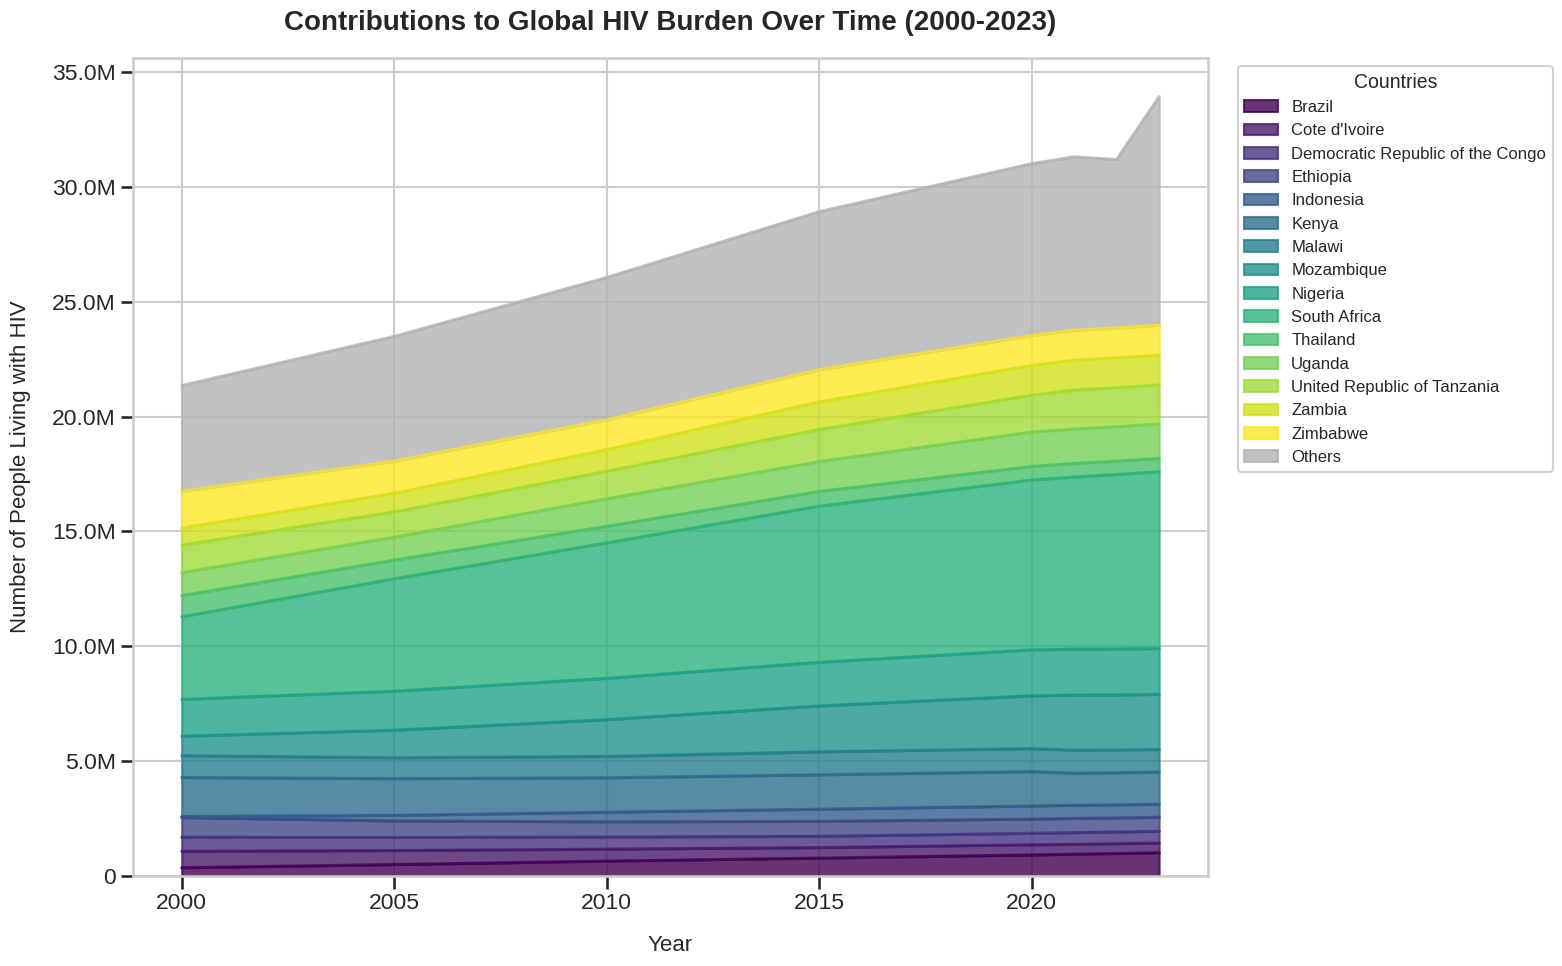

In [31]:
create_stacked_area_chart(hiv_merged, top_countries_df)

- Creating a horizontal bar chart to show Ranking of People per Country living with HIV making up top 75% of the global burden throughout year 2000 - 2023

In [32]:
# Create a horizontal bar chart showing the ranking
def create_bar_chart(top_countries_df):
    # Sort by value for better visualization
    sorted_df = top_countries_df.sort_values('NumericValue')
    
    fig, ax = plt.subplots(figsize=(14, 10))
    
    # Create a colormap
    colors = plt.cm.viridis(np.linspace(0, 1, len(sorted_df)))
    
    # Create horizontal bar chart
    bars = ax.barh(sorted_df['Location'], sorted_df['NumericValue'], color=colors)
    
    # Add value labels at the end of each bar
    for i, bar in enumerate(bars):
        width = bar.get_width()
        label_x_pos = width * 1.01
        ax.text(label_x_pos, bar.get_y() + bar.get_height()/2, 
                format_number(width, 0), va='center', fontsize=12)
    
    # Formatting
    ax.set_title('Countries Contributing to 75% of Global HIV Burden (2000-2023)', 
                 fontsize=20, fontweight='bold', pad=20)
    ax.set_xlabel('Number of People Living with HIV', fontsize=16, labelpad=15)
    ax.set_ylabel('Countries', fontsize=16, labelpad=15)
    
    # Format x-axis to show millions/thousands
    ax.xaxis.set_major_formatter(FuncFormatter(format_number))
    
    # Add a text showing the selection criteria
    total_percentage = top_countries_df['Percentage'].sum() * 100
    plt.figtext(0.2, 0.01, 
                f"These {len(top_countries_df)} countries represent {total_percentage:.1f}% of global HIV burden",
                ha="center", fontsize=12, bbox={"boxstyle":"round,pad=0.5", "facecolor":"white", "alpha":0.8})
    
    plt.tight_layout()
    plt.close(fig)
    
    return fig

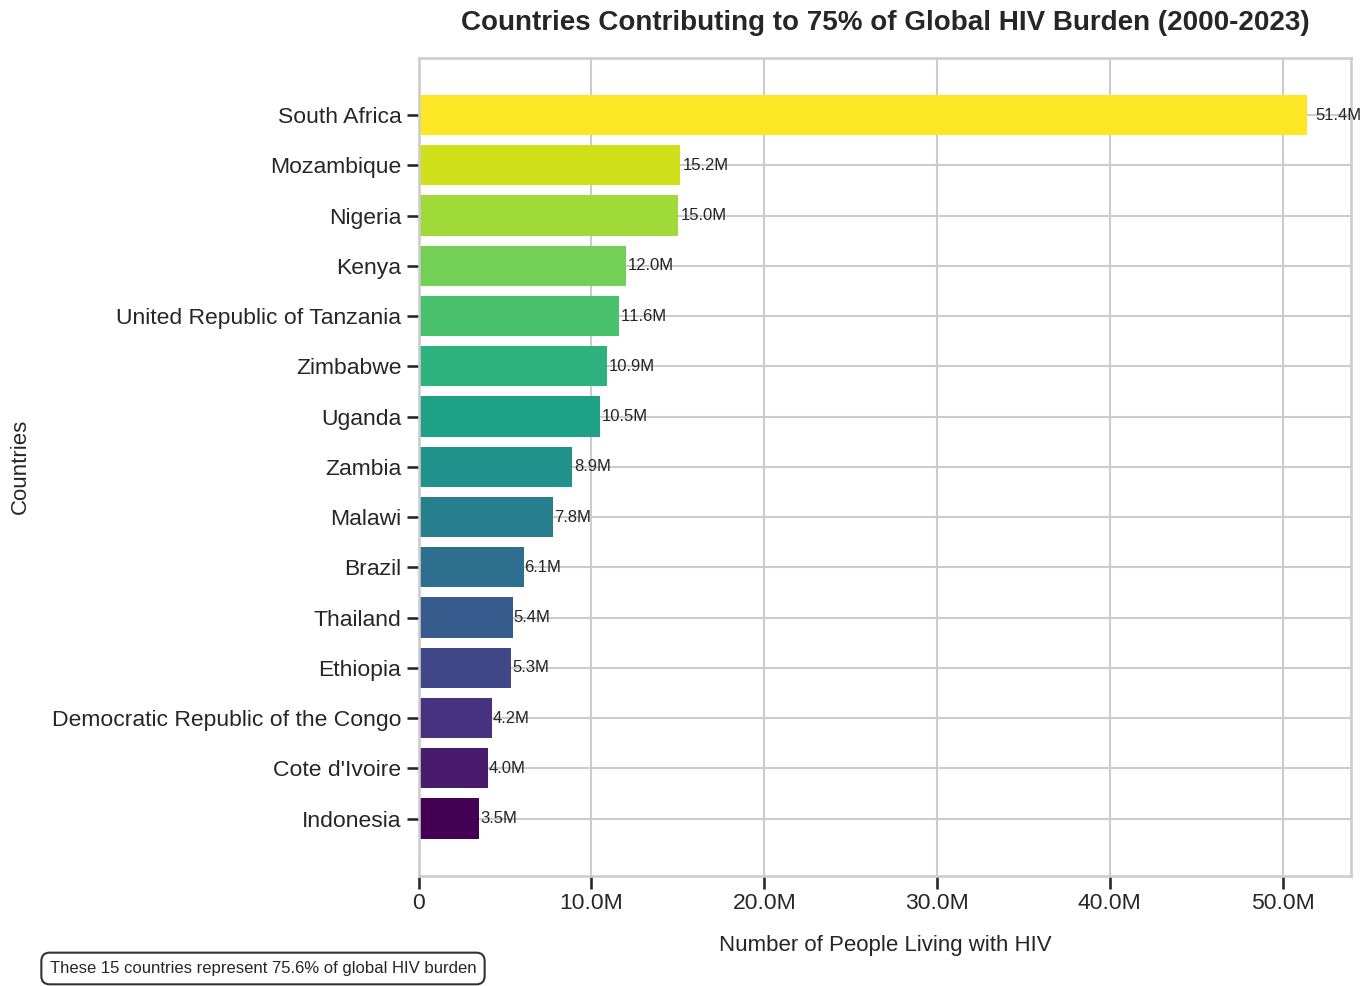

In [33]:
# Visualizing BarChart showing top 75% countries

create_bar_chart(top_countries_df)

In [34]:
# Create a pie chart showing the latest distribution

def create_pie_chart(top_countries_df):
    fig, ax = plt.subplots(figsize=(12, 12))
    
    # Extract data for pie chart
    labels = top_countries_df['Location'].tolist()
    sizes = top_countries_df['NumericValue'].tolist()
    percentages = top_countries_df['Percentage'].tolist()
    
    # Create custom labels with both country name and percentage
    pie_labels = [f"{label} ({percent:.1%})" for label, percent in zip(labels, percentages)]
    
    # Create a colormap
    colors = plt.cm.viridis(np.linspace(0, 1, len(labels)))
    
    # Create pie chart with customizations
    wedges, texts, autotexts = ax.pie(
        sizes, 
        labels=None,  # We'll add custom labels outside
        autopct='%1.1f%%', 
        startangle=90, 
        colors=colors,
        pctdistance=0.85,
        wedgeprops=dict(width=0.4, edgecolor='w')  # Create a donut chart effect
    )
    
    # Style the autopct labels
    plt.setp(autotexts, size=10, weight="bold", color="white")
    
    # Create a white circle in the middle for a better donut chart
    centre_circle = plt.Circle((0, 0), 0.5, fc='white')
    ax.add_patch(centre_circle)
    
    # Add a legend with the custom labels
    ax.legend(wedges, pie_labels, title="Countries", 
              loc="center left", bbox_to_anchor=(1, 0, 0.5, 1))
    
    # Add title
    ax.set_title('Distribution of HIV Burden Among Top Contributing Countries (2000-2023)', 
                 fontsize=18, fontweight='bold', pad=20)

    # Add a text showing the selection criteria
    total_percentage = top_countries_df['Percentage'].sum() * 100
    plt.figtext(0.2, 0.01, 
                f"These {len(top_countries_df)} countries represent {total_percentage:.1f}% of global HIV burden",
                ha="center", fontsize=12, bbox={"boxstyle":"round,pad=0.5", "facecolor":"white", "alpha":0.8})

    plt.tight_layout()
    plt.close(fig)
    
    return fig

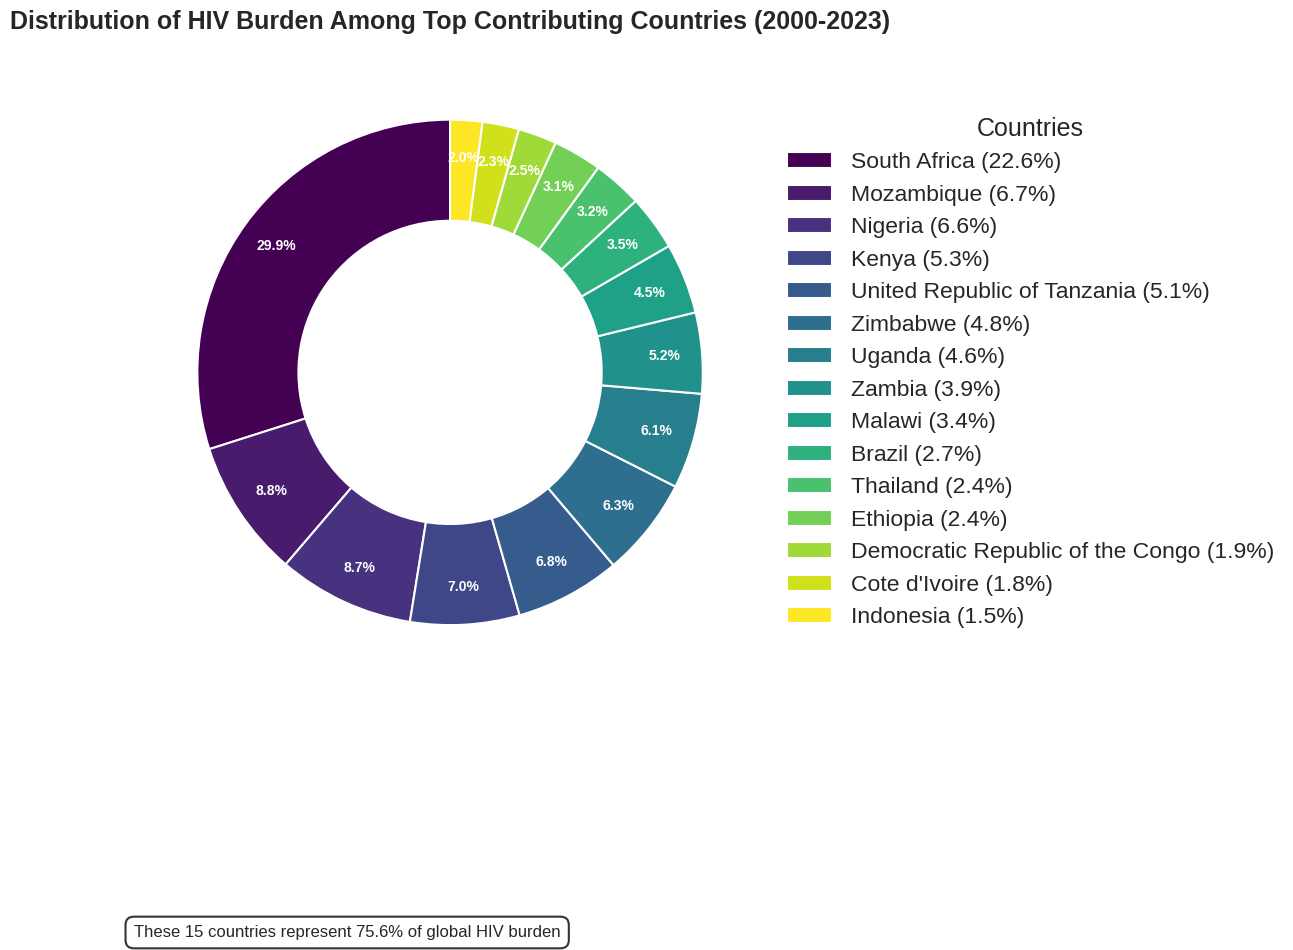

In [35]:
# Visualizing distribution of the top 75% countries contributing to the global burden from years 2000 - 2023

create_pie_chart(top_countries_df)

### Countries Contributing to 75% of the Global HIV Burden (2000–2023)

Our analysis shows that just **15 countries account for approximately 75% of the global HIV burden** between 2000 and 2023. The leading contributors are:

1. **South Africa** — 22.61%
2. **Mozambique** — 6.67%
3. **Nigeria** — 6.60%
4. **Kenya** — 5.28%
5. **United Republic of Tanzania** — 5.10%
6. **Zimbabwe** — 4.80%
7. **Uganda** — 4.62%
8. **Zambia** — 3.91%
9. **Malawi** — 3.41%
10. **Brazil** — 2.67%
11. **Thailand** — 2.39%
12. **Ethiopia** — 2.35%
13. **Democratic Republic of the Congo** — 1.87%
14. **Côte d'Ivoire** — 1.77%
15. **Indonesia** — 1.55%

**Summary:**  
The majority of the HIV burden is concentrated in a small number of countries, predominantly in Sub-Saharan Africa. South Africa alone accounts for more than 20% of global cases. This concentration highlights the need for targeted, region-specific public health strategies and interventions.

In [36]:
# Most Recent Year in HIV data

most_recent_year = hiv_merged["Period"].max()
print(f"The most Recent year in our HIV data is: {most_recent_year}")

The most Recent year in our HIV data is: 2023


### **Calculate For Most Recent Countries contributing to 75% of the Global Burdern i.e., Year 2023** 

- I will now create a function to identify countries contributing to 75% of global burden for the most recent year

In [37]:
# Function to identify countries contributing to 75% of global burden for latest year 2023

def get_top_burden_countries_2023(df, threshold=0.75):

    # Calculate latest year 2023 total cases by country
    year = df["Period"].max()
    data = df[df["Period"] == year]

    # Group by countrycode and country then sum the total HIV cases and sort them in descending order
    country_totals = (
        data.groupby(["SpatialDimValueCode", "Location"])["NumericValue"]
        .sum()
        .sort_values(ascending=False)
    )

    # Prepare result DataFrame
    country_totals_df = country_totals.reset_index()
    country_totals_df.rename(columns={"SpatialDimValueCode": "LocationCode"}, inplace=True)

    # Compute percentages
    global_total = country_totals_df["NumericValue"].sum()
    country_totals_df["Percentage"] = country_totals_df["NumericValue"] / global_total
    country_totals_df["CumulativePercentage"] = country_totals_df["Percentage"].cumsum()

    # Select top contributors that make up 75% of total global burden
    top_countries_df_2023 = country_totals_df[country_totals_df["CumulativePercentage"] <= threshold]

    # Ensure threshold is crossed
    if not top_countries_df_2023.empty and top_countries_df_2023["CumulativePercentage"].iloc[-1] < threshold:
        next_country = country_totals_df.iloc[len(top_countries_df_2023)]
        top_countries_df_2023 = pd.concat([top_countries_df_2023, next_country.to_frame().T], ignore_index=True)

    return top_countries_df_2023

In [38]:
# Get the top 75% countries contributing to the global HIV burden from our hiv_merged dataframe in 2023

top_countries_df_2023 = get_top_burden_countries_2023(hiv_merged)

In [39]:
# Examining the recent top 75% countries contributing to the global burden for year 2023

top_countries_df_2023

,LocationCode,Location,NumericValue,Percentage,CumulativePercentage
0,ZAF,South Africa,7700000,0.226911,0.226911
1,IND,India,2500000,0.073672,0.300584
2,MOZ,Mozambique,2400000,0.070726,0.371309
3,NGA,Nigeria,2000000,0.058938,0.430247
4,TZA,United Republic of Tanzania,1700000,0.050097,0.480344
5,UGA,Uganda,1500000,0.044203,0.524548
6,KEN,Kenya,1400000,0.041257,0.565804
7,ZWE,Zimbabwe,1300000,0.03831,0.604114
8,ZMB,Zambia,1300000,0.03831,0.642424
9,BRA,Brazil,1000000,0.029469,0.671893


In [40]:
# Get top countries' location codes from the top_75_global DataFrame
top_country_codes_2023 = top_countries_df_2023['LocationCode'].tolist()

# Filtering the main HIV dataset to only include these top countries
top_countries_data_2023 = hiv_merged[hiv_merged['SpatialDimValueCode'].isin(top_country_codes_2023)]

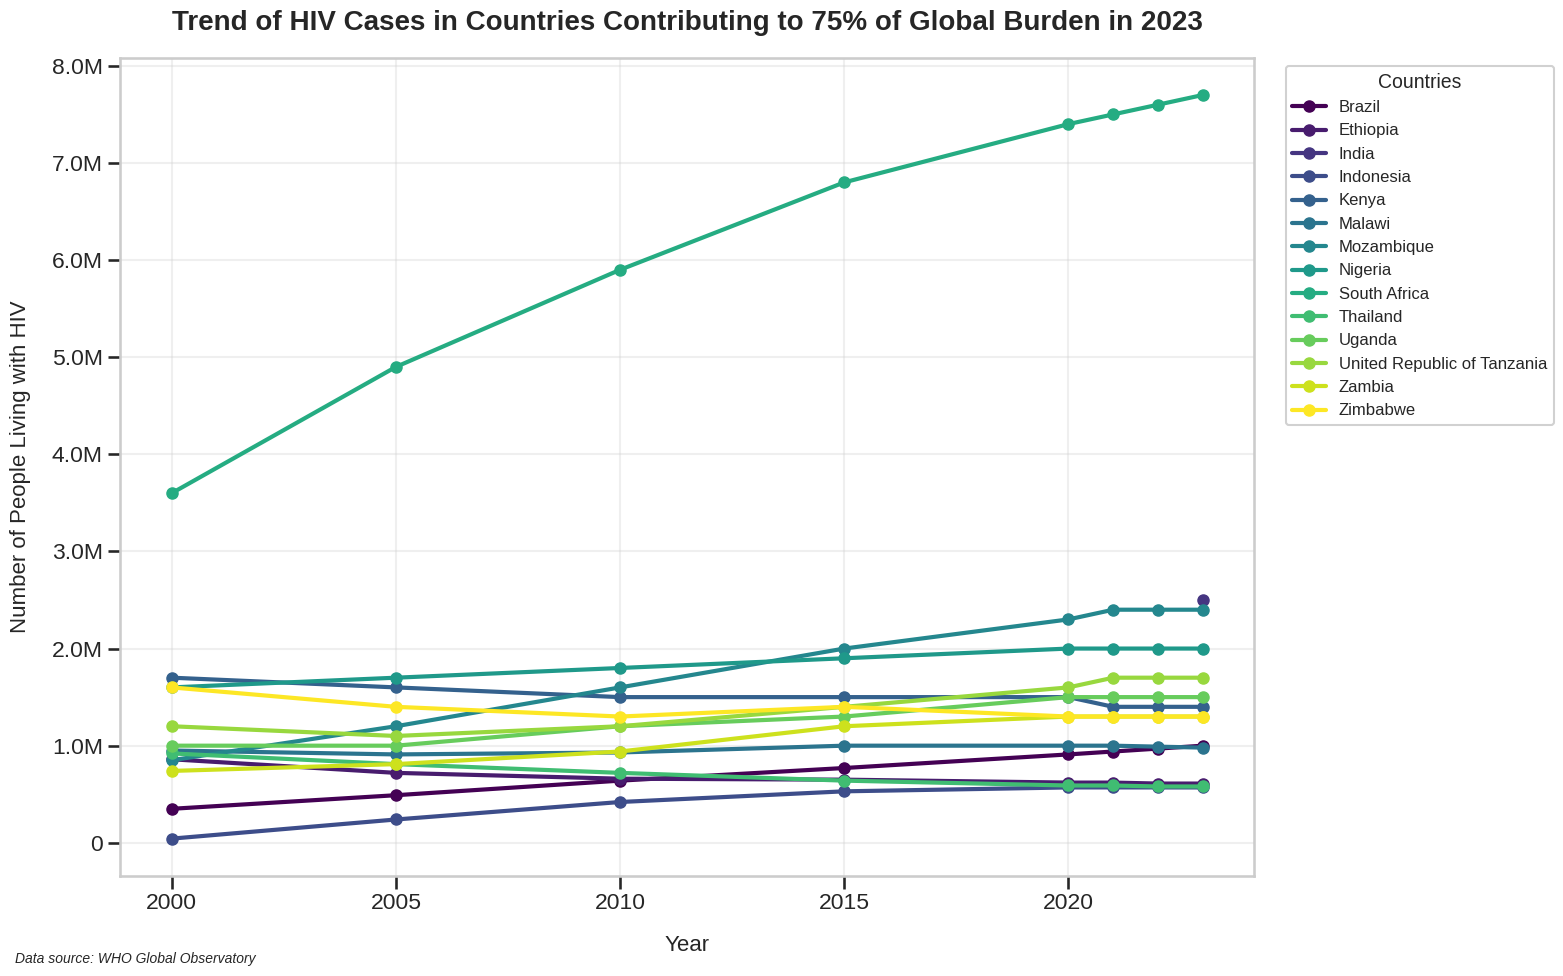

In [41]:
# Create a pivot table where each country is a column and years are rows for most countries making up 75% in 2023
timeline_data = top_countries_data_2023.pivot_table(
    index='Period',
    columns='Location',
    values='NumericValue',
    aggfunc='sum'  # or 'sum' if multiple entries per year exist
)

# Setup the plot
fig, ax = plt.subplots(figsize=(16, 10))

# Generate a colormap with enough distinct colors for the countries
colors = plt.cm.viridis(np.linspace(0, 1, len(timeline_data.columns)))

# Plotting the data
for i, country in enumerate(timeline_data.columns):
    ax.plot(
        timeline_data.index, 
        timeline_data[country],
        label=country,
        color=colors[i],
        linewidth=3,
        marker='o',
        markersize=8
    )

# Format the axes and add titles
ax.set_title('Trend of HIV Cases in Countries Contributing to 75% of Global Burden in 2023', 
             fontsize=20, fontweight='bold', pad=20)
ax.set_xlabel('Year', fontsize=16, labelpad=15)
ax.set_ylabel('Number of People Living with HIV', fontsize=16, labelpad=15)
ax.yaxis.set_major_formatter(FuncFormatter(format_number))

# Add a subtle grid for readability
ax.grid(True, alpha=0.3)

# Add a legend outside the plot
legend = ax.legend(
    title="Countries", 
    title_fontsize=14, 
    fontsize=12,
    bbox_to_anchor=(1.02, 1), 
    loc='upper left', 
    frameon=True
)
legend.get_frame().set_alpha(0.9)

# Add a text annotation about data source
plt.figtext(0.02, 0.02, 'Data source: WHO Global Observatory', fontsize=10, style='italic')

# Layout adjustment and display the plot
plt.tight_layout()
plt.show();

In [42]:
# Sort the top_countries_df_2023 by Percentage in descending order
top_countries_df_2023 = top_countries_df_2023.sort_values(by='Percentage', ascending=False).reset_index(drop=True)

# Header for the output
print("Most Recent Countries contributing to 75% of global HIV burden (based on 2023 data):")

# Loop through and print each country with its contribution
for i, row in top_countries_df_2023.iterrows():
    country = row['Location']
    percentage = row['Percentage'] * 100  # Convert to percentage
    print(f"{i+1}. {country}: {percentage:.2f}%")


Most Recent Countries contributing to 75% of global HIV burden (based on 2023 data):
1. South Africa: 22.69%
2. India: 7.37%
3. Mozambique: 7.07%
4. Nigeria: 5.89%
5. United Republic of Tanzania: 5.01%
6. Uganda: 4.42%
7. Kenya: 4.13%
8. Zimbabwe: 3.83%
9. Zambia: 3.83%
10. Brazil: 2.95%
11. Malawi: 2.89%
12. Ethiopia: 1.80%
13. Thailand: 1.71%
14. Indonesia: 1.68%


- Creating a horizontal bar chart to show Ranking of People per Country living with HIV making up top 75% of the global burden in year 2023

In [43]:
# Create a horizontal bar chart showing the ranking
def create_bar_chart_2023(top_countries_df_2023):
    # Sort by value for better visualization
    sorted_df = top_countries_df_2023.sort_values('NumericValue')
    
    fig, ax = plt.subplots(figsize=(14, 10))
    
    # Create a colormap
    colors = plt.cm.viridis(np.linspace(0, 1, len(sorted_df)))
    
    # Create horizontal bar chart
    bars = ax.barh(sorted_df['Location'], sorted_df['NumericValue'], color=colors)
    
    # Add value labels at the end of each bar
    for i, bar in enumerate(bars):
        width = bar.get_width()
        label_x_pos = width * 1.01
        ax.text(label_x_pos, bar.get_y() + bar.get_height()/2, 
                format_number(width, 0), va='center', fontsize=12)
    
    # Formatting
    ax.set_title('Countries Contributing to 75% of Global HIV Burden (In year 2023)', 
                 fontsize=20, fontweight='bold', pad=20)
    ax.set_xlabel('Number of People Living with HIV', fontsize=16, labelpad=15)
    ax.set_ylabel('Countries', fontsize=16, labelpad=15)
    
    # Format x-axis to show millions/thousands
    ax.xaxis.set_major_formatter(FuncFormatter(format_number))
    
    # Add a text showing the selection criteria
    total_percentage = top_countries_df_2023['Percentage'].sum() * 100
    plt.figtext(0.2, 0.01, 
                f"These {len(top_countries_df_2023)} countries represent {total_percentage:.1f}% of global HIV burden",
                ha="center", fontsize=12, bbox={"boxstyle":"round,pad=0.5", "facecolor":"white", "alpha":0.8})
    
    plt.tight_layout()
    plt.close(fig)
    
    return fig

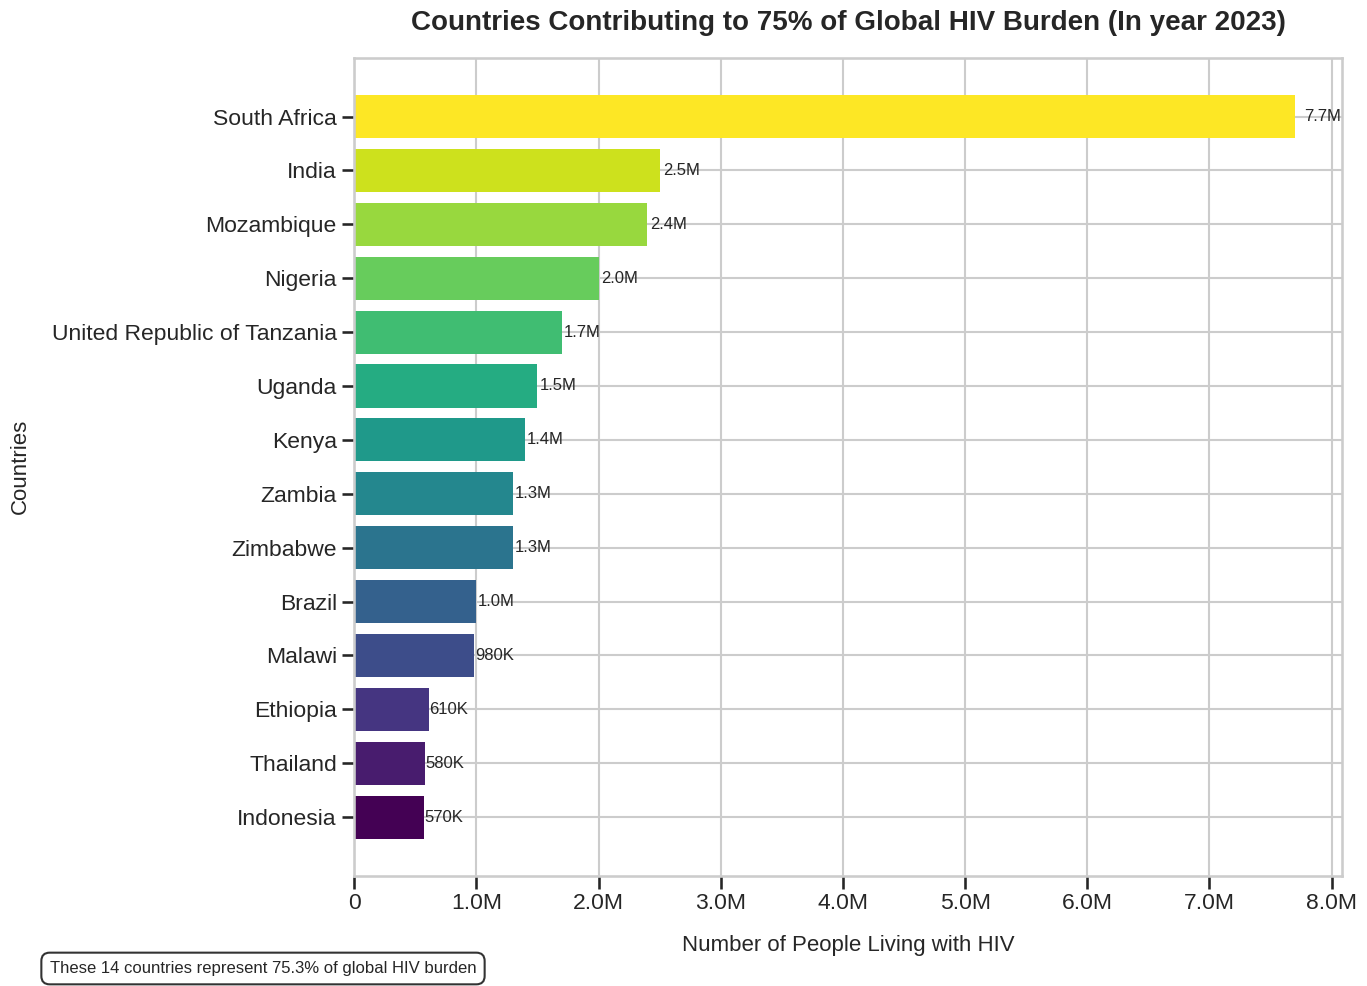

In [44]:
# Visualizing BarChart showing top 75% countries accounting for global burden in year 2023

create_bar_chart_2023(top_countries_df_2023)

In [45]:
# Create a pie chart showing the latest distribution

def create_pie_chart_2023(top_countries_df_2023):
    fig, ax = plt.subplots(figsize=(12, 12))
    
    # Extract data for pie chart
    labels = top_countries_df_2023['Location'].tolist()
    sizes = top_countries_df_2023['NumericValue'].tolist()
    percentages = top_countries_df_2023['Percentage'].tolist()
    
    # Create custom labels with both country name and percentage
    pie_labels = [f"{label} ({percent:.1%})" for label, percent in zip(labels, percentages)]
    
    # Create a colormap
    colors = plt.cm.viridis(np.linspace(0, 1, len(labels)))
    
    # Create pie chart with customizations
    wedges, texts, autotexts = ax.pie(
        sizes, 
        labels=None,  # We'll add custom labels outside
        autopct='%1.1f%%', 
        startangle=90, 
        colors=colors,
        pctdistance=0.85,
        wedgeprops=dict(width=0.4, edgecolor='w')  # Create a donut chart effect
    )
    
    # Style the autopct labels
    plt.setp(autotexts, size=10, weight="bold", color="white")
    
    # Create a white circle in the middle for a better donut chart
    centre_circle = plt.Circle((0, 0), 0.5, fc='white')
    ax.add_patch(centre_circle)
    
    # Add a legend with the custom labels
    ax.legend(wedges, pie_labels, title="Countries", 
              loc="center left", bbox_to_anchor=(1, 0, 0.5, 1))
    
    # Add title
    ax.set_title('Distribution of HIV Burden Among Top Contributing Countries for Year 2023', 
                 fontsize=18, fontweight='bold', pad=20)

    # Add a text showing the selection criteria
    total_percentage = top_countries_df_2023['Percentage'].sum() * 100
    plt.figtext(0.2, 0.01, 
                f"These {len(top_countries_df_2023)} countries represent {total_percentage:.1f}% of global HIV burden",
                ha="center", fontsize=12, bbox={"boxstyle":"round,pad=0.5", "facecolor":"white", "alpha":0.8})
    
    plt.tight_layout()
    plt.close(fig)
    
    return fig

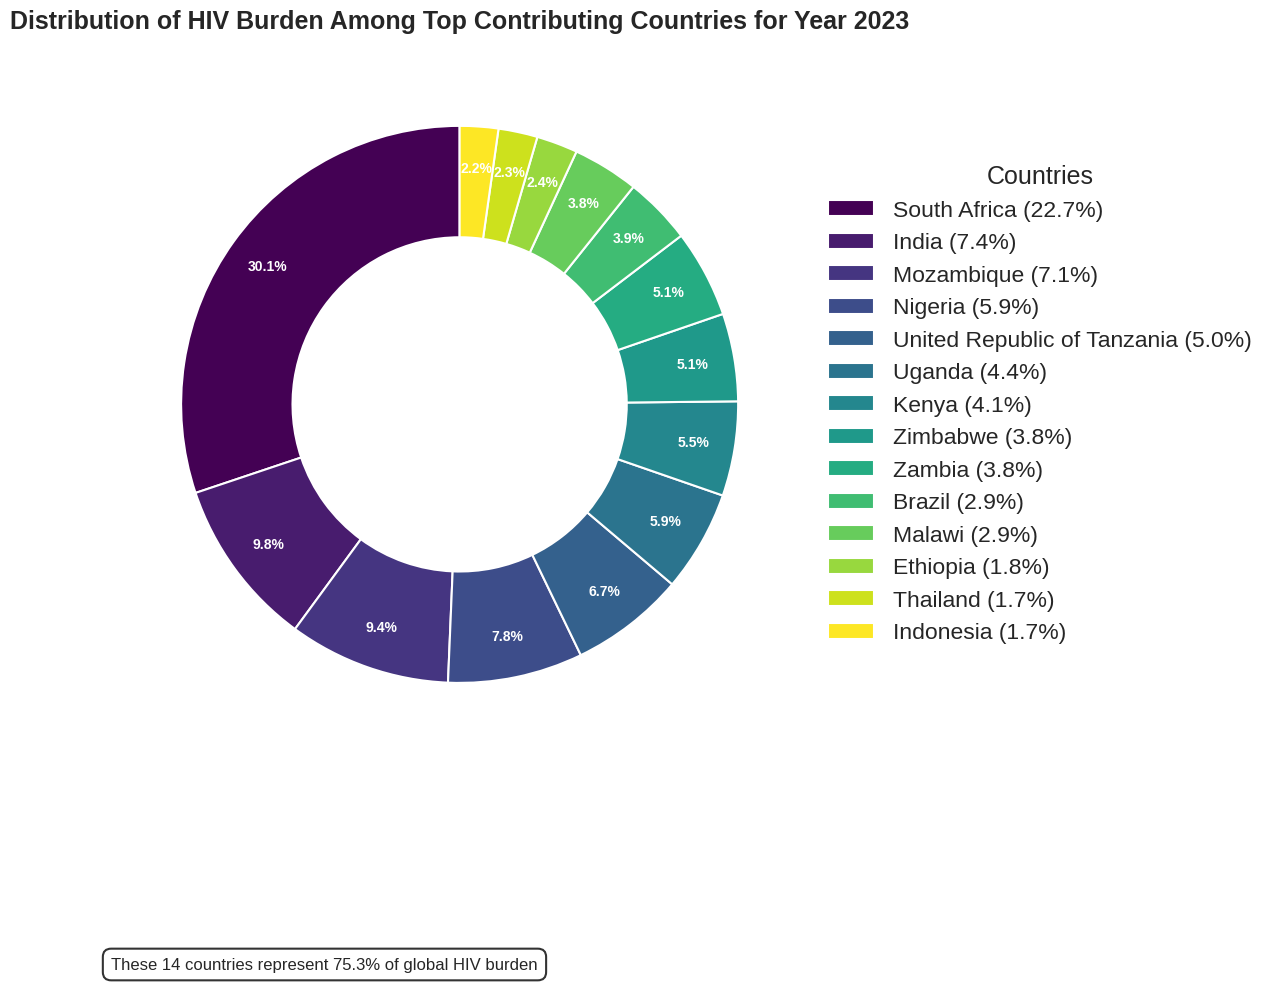

In [46]:
# Visualizing distribution of the top 75% countries contributing to the global burden for year 2023

create_pie_chart_2023(top_countries_df_2023)

- Create a stacked area chart showing the contribution over time for countries that make up top 75% of the global burden for the year 2023

In [47]:
# Create a stacked area chart showing the contribution over time
def create_stacked_area_chart_2023(hiv_data, top_countries_df_2023):
    # Get the top country codes
    top_country_codes = top_countries_df_2023['LocationCode'].tolist()
    
    # Filter data for top countries
    top_countries_data = hiv_data[hiv_data['SpatialDimValueCode'].isin(top_country_codes)]
    
    # Create pivot table
    pivot_data = top_countries_data.pivot_table(
        index='Period', 
        columns='Location', 
        values='NumericValue',
        aggfunc='sum'
    )
    
    # Calculate 'Others' category (global total minus top countries)
    years = pivot_data.index.unique()
    others_values = []
    
    for year in years:
        year_data = hiv_data[hiv_data['Period'] == year]
        global_total = year_data['NumericValue'].sum()
        top_total = year_data[year_data['SpatialDimValueCode'].isin(top_country_codes)]['NumericValue'].sum()
        others_values.append(global_total - top_total)
    
    # Add 'Others' to the pivot table
    pivot_data['Others'] = others_values
    
    # Create stacked area chart
    fig, ax = plt.subplots(figsize=(16, 10))
    
    # Get a nice colormap with enough distinct colors
    colors = plt.cm.viridis(np.linspace(0, 1, len(pivot_data.columns)-1))  # -1 for 'Others'
    
    # Add a gray color for 'Others'
    all_colors = list(colors) + [(0.7, 0.7, 0.7, 1.0)]
    
    # Plot stacked area
    pivot_data.plot.area(ax=ax, stacked=True, color=all_colors, alpha=0.8)
    
    # Formatting
    ax.set_title('Contributions to Global HIV Burden Over Time (2000-2023) for countries that make up top 75% of the global burden for the year 2023', 
                 fontsize=20, fontweight='bold', pad=20)
    ax.set_xlabel('Year', fontsize=16, labelpad=15)
    ax.set_ylabel('Number of People Living with HIV', fontsize=16, labelpad=15)
    
    # Format y-axis to show millions/thousands
    ax.yaxis.set_major_formatter(FuncFormatter(format_number))
    
    # Improve legend
    legend = ax.legend(title="Countries", title_fontsize=14, fontsize=12, 
                       bbox_to_anchor=(1.02, 1), loc='upper left', frameon=True)
    legend.get_frame().set_alpha(0.9)
    
    plt.tight_layout()

    plt.close(fig)
    
    return fig


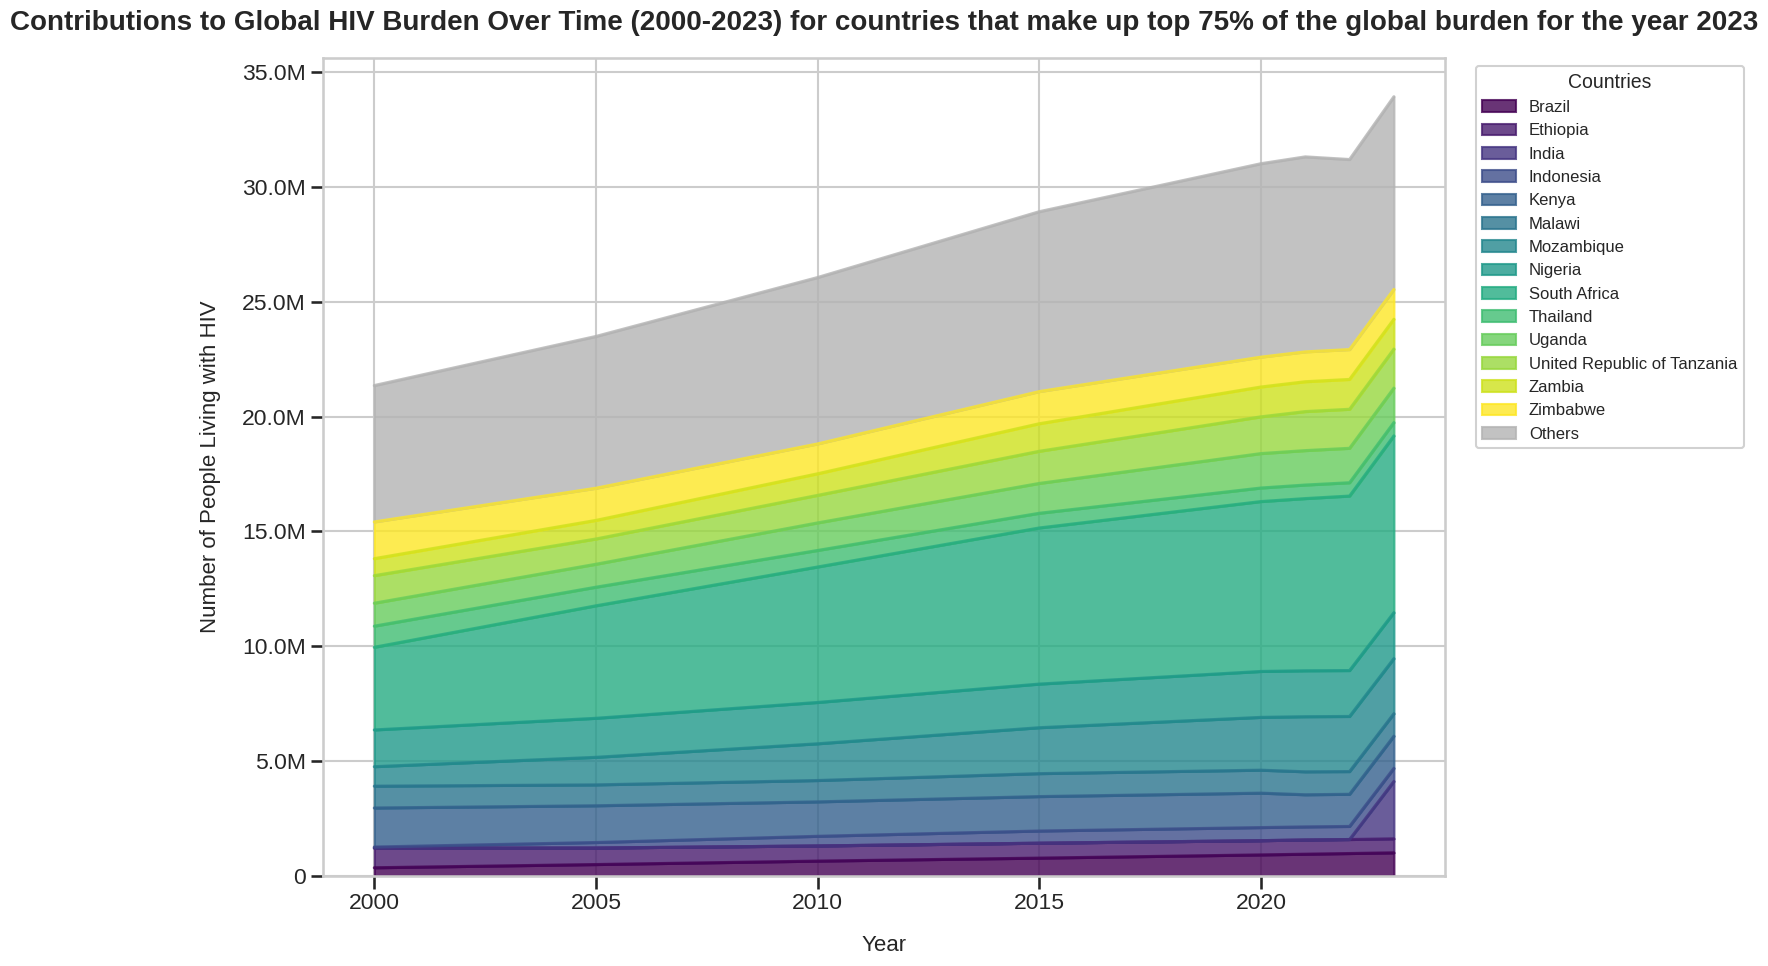

In [48]:
# Visualizing the stacked chart

create_stacked_area_chart_2023(hiv_merged, top_countries_df_2023)

#### Countries Contributing to 75% of the Global HIV Burden (2023)

The most recent data from 2023 reveals that **14 countries account for approximately 75% of the global HIV burden**. These countries are:

1. **South Africa** — 22.69%
2. **India** — 7.37%
3. **Mozambique** — 7.07%
4. **Nigeria** — 5.89%
5. **United Republic of Tanzania** — 5.01%
6. **Uganda** — 4.42%
7. **Kenya** — 4.13%
8. **Zimbabwe** — 3.83%
9. **Zambia** — 3.83%
10. **Brazil** — 2.95%
11. **Malawi** — 2.89%
12. **Ethiopia** — 1.80%
13. **Thailand** — 1.71%
14. **Indonesia** — 1.68%

**Summary:**  
South Africa remains the largest contributor to global HIV cases. Notably, **India** has emerged as the second largest contributor in 2023, overtaking several African nations. This change reflects shifting regional dynamics in the global HIV epidemic.




### **Comparison Between 2000–2023 Cumulative Data and 2023 Data Alone**

**Key Differences:**

- **India**:  
  - *Cumulative (2000–2023)*: India was **not** among the top 15 contributors.
  - *2023*: India is now ranked **2nd**, contributing **7.37%** of global HIV burden.

- **Côte d'Ivoire and Democratic Republic of the Congo**:  
  - Present in the cumulative list, but **no longer among the top contributors** based on 2023 data.

- **Number of Countries**:  
  - *2000–2023*: 15 countries contributed to 75% of the burden.
  - *2023*: Only 14 countries are needed to reach 75%.

- **Regional Shift**:  
  - While Sub-Saharan Africa still dominates, **Asia's share (through India and Indonesia)** has increased in the 2023 figures.

**Summary:**  
The 2023 data shows a slight **geographic shift in the global HIV burden**, with **India's increasing share** and **some African countries like Côte d'Ivoire and DRC** falling out of the top group. This suggests changing epidemic patterns and the need for updated regional strategies.


## **QUESTION 1.2: Generate a visualization that displays the trend of HIV cases in the countries contributing to 75% of the burden within each WHO region (column called ParentLocationCode contains the WHO regions)**

### **A.) Visualizations of top countries contributing to 75% of the burden within each WHO region throughout 2000-2023(All Time)**

Africa (AFR)
 - South Africa: 35.27%
 - Mozambique: 10.99%
 - Nigeria: 9.16%
 - United Republic of Tanzania: 7.79%
 - Uganda: 6.87%
 - Kenya: 6.41%
 - Zambia: 5.96%
 - Zimbabwe: 5.96%
 - Malawi: 4.49%
 - Ethiopia: 2.79%
 - Democratic Republic of the Congo: 2.38%
 - Cote d'Ivoire: 1.92%




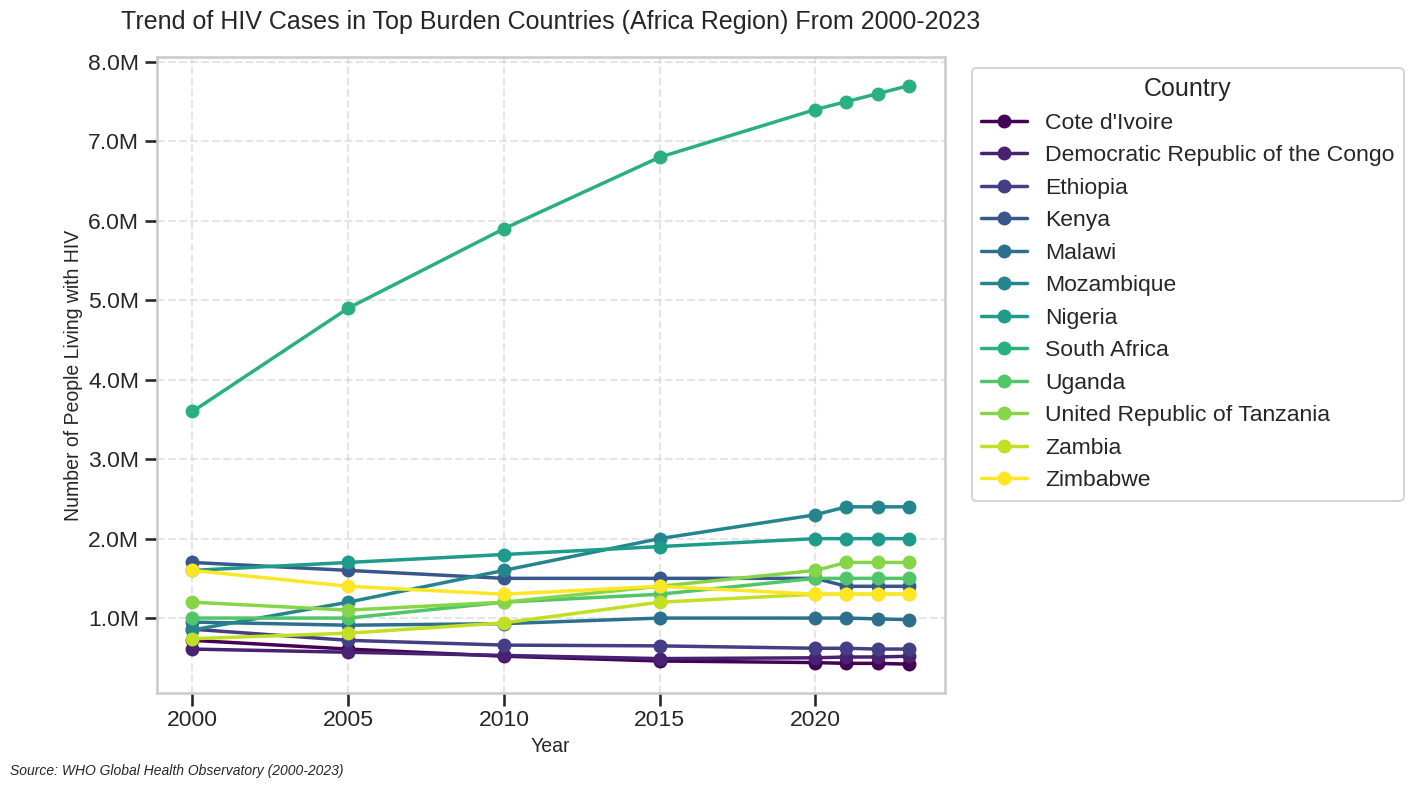

Americas (AMR)
 - Brazil: 100.00%




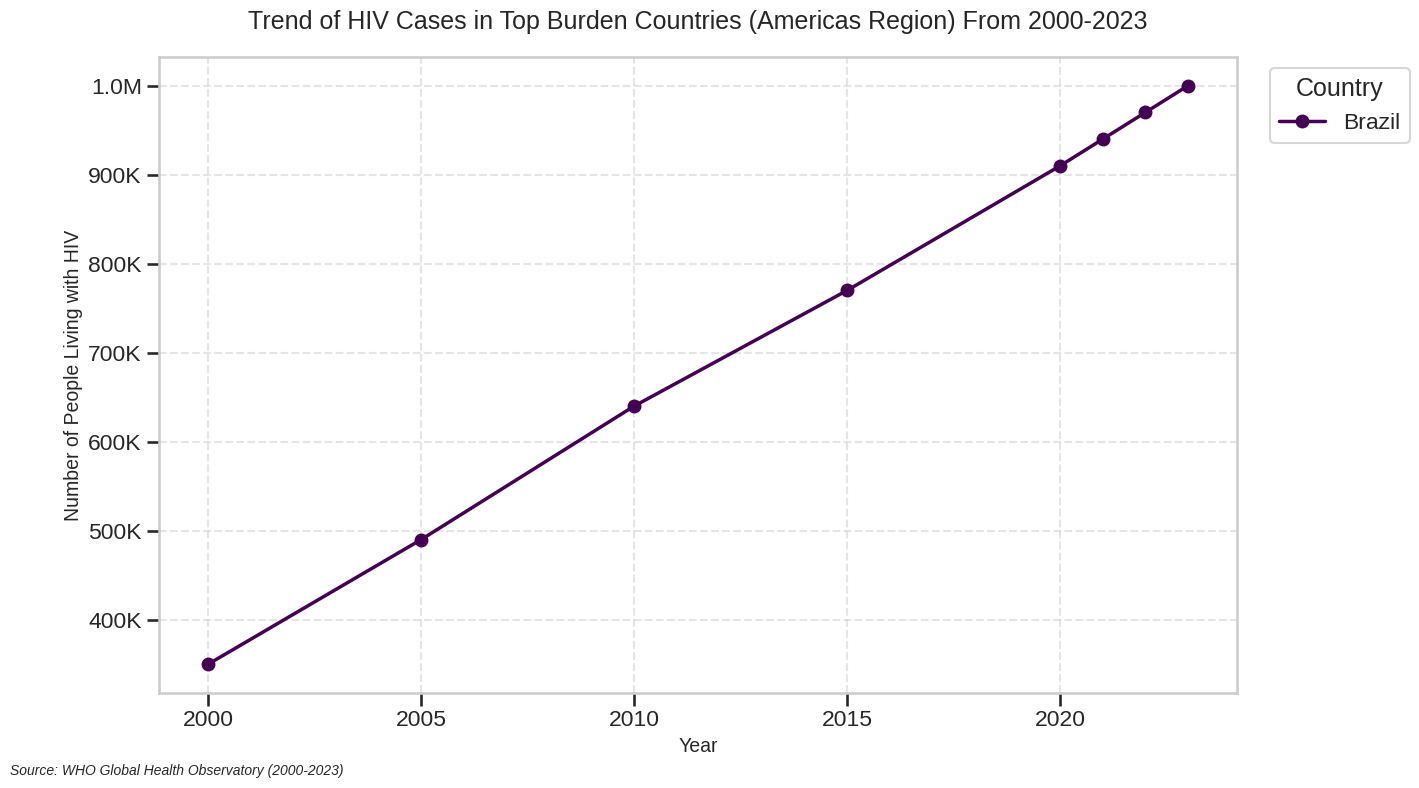

South-East Asia (SEAR)
 - Thailand: 50.43%
 - Indonesia: 49.57%




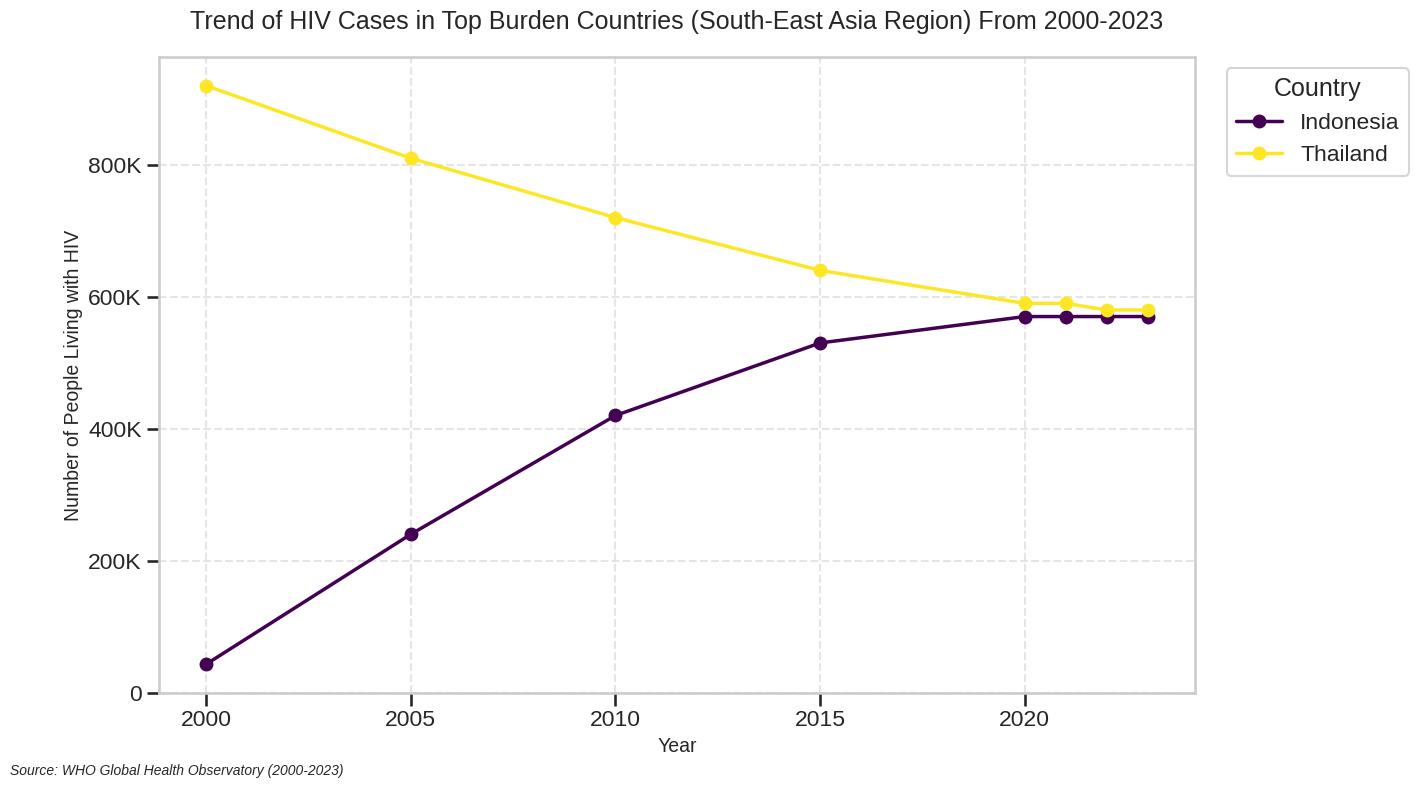

In [49]:
# Get list of WHO regions
who_regions = top_countries_data['ParentLocationCode'].unique()



# Loop through each region and generate a chart
for region_code in who_regions:
    # Get name of region
    region_name = top_countries_data[top_countries_data['ParentLocationCode'] == region_code]['ParentLocation'].iloc[0]
    
    # Filter for only this region
    region_data = top_countries_data[top_countries_data['ParentLocationCode'] == region_code]

    # Filter for the most recent year
    recent_region_data = region_data[region_data['Period'] == most_recent_year].copy()

    # Calculate region total
    region_total = recent_region_data['NumericValue'].sum()

    # Calculate percentage per country
    recent_region_data['PercentOfRegion'] = (recent_region_data['NumericValue'] / region_total) * 100

    # Sort by percentage
    sorted_region = recent_region_data.sort_values('PercentOfRegion', ascending=False)

    # Print region and country percentages
    print(f"{region_name} ({region_code})")
    for _, row in sorted_region.iterrows():
        country = row['Location']
        pct = row['PercentOfRegion']
        print(f" - {country}: {pct:.2f}%")
    print("\n")

    # Pivot table: Year vs Country values
    timeline_data = region_data.pivot_table(
        index='Period',  # or 'Year' if that's your column
        columns='Location',
        values='NumericValue',
        aggfunc='sum'
    )

    # Sort years
    timeline_data = timeline_data.sort_index()

    # Setup plot
    fig, ax = plt.subplots(figsize=(14, 8))
    colors = plt.cm.viridis(np.linspace(0, 1, len(timeline_data.columns)))

    for i, country in enumerate(timeline_data.columns):
        ax.plot(
            timeline_data.index,
            timeline_data[country],
            label=country,
            color=colors[i],
            linewidth=2.5,
            marker='o'
        )

    ax.set_title(f'Trend of HIV Cases in Top Burden Countries ({region_name} Region) From 2000-2023', fontsize=18, pad=20)
    ax.set_xlabel('Year', fontsize=14)
    ax.set_ylabel('Number of People Living with HIV', fontsize=14)
    ax.yaxis.set_major_formatter(FuncFormatter(format_number))
    ax.grid(True, linestyle='--', alpha=0.5)

    # Legend formatting
    ax.legend(title="Country", bbox_to_anchor=(1.02, 1), loc='upper left', frameon=True)

    # Source + annotation
    plt.figtext(0.1, 0.01, 'Source: WHO Global Health Observatory (2000-2023)', ha='center', fontsize=10, style='italic')

    plt.tight_layout()
    plt.show();

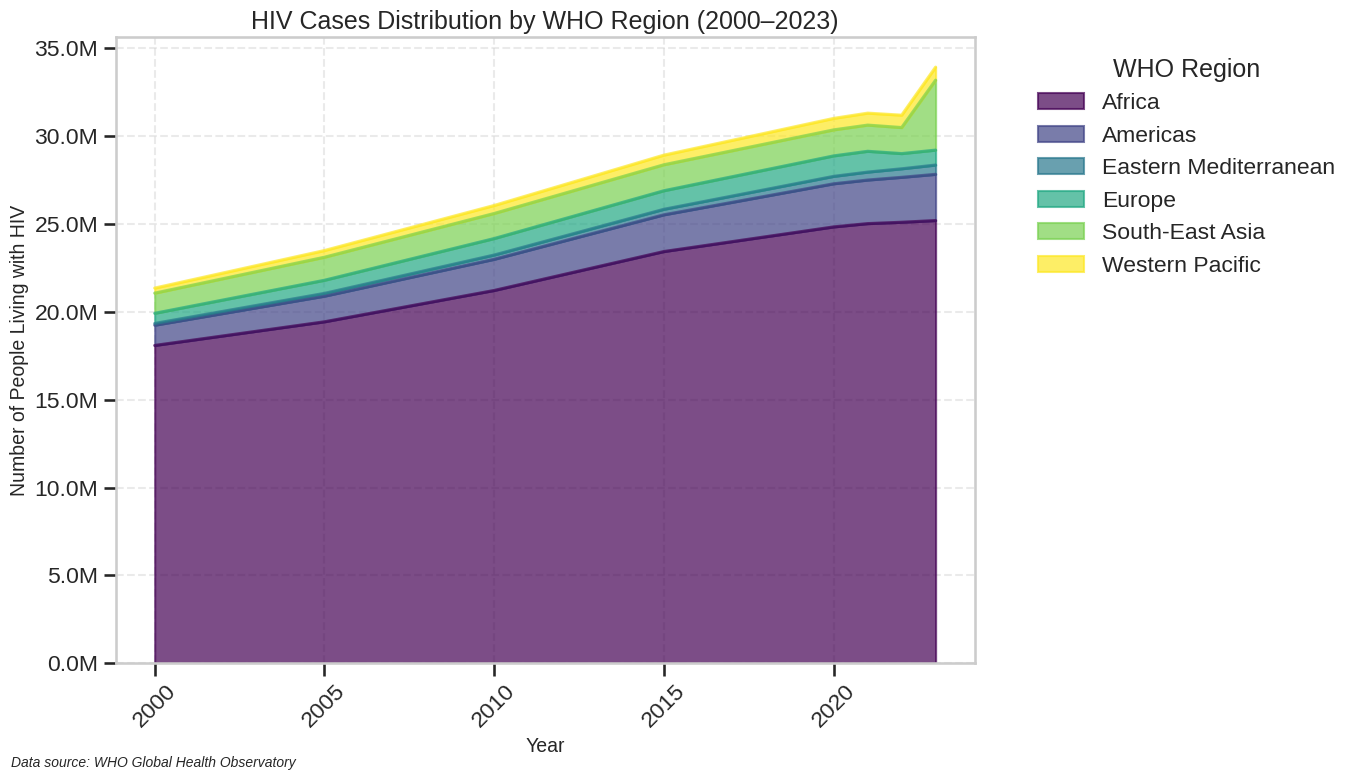

In [50]:
# Regional trends over time (stacked area chart)
regional_totals = hiv_merged.groupby(['Period', 'ParentLocationCode', 'ParentLocation'])['NumericValue'].sum().reset_index()

# Pivot for plotting
regional_pivot = regional_totals.pivot_table(
    index='Period', 
    columns='ParentLocation', 
    values='NumericValue'
).sort_index()

# Plot stacked area chart
plt.figure(figsize=(14, 8))
regional_pivot.plot.area(stacked=True, alpha=0.7, ax=plt.gca(), colormap='viridis')

plt.title('HIV Cases Distribution by WHO Region (2000–2023)', fontsize=18)
plt.xlabel('Year', fontsize=14)
plt.ylabel('Number of People Living with HIV', fontsize=14)
plt.xticks(rotation=45)
plt.grid(True, linestyle='--', alpha=0.4)

plt.legend(title='WHO Region', bbox_to_anchor=(1.05, 1), loc='upper left')

# Format y-axis
plt.gca().yaxis.set_major_formatter(FuncFormatter(lambda x, _: f'{x/1_000_000:.1f}M'))

plt.figtext(0.02, 0.02, 'Data source: WHO Global Health Observatory', fontsize=10, style='italic')
plt.tight_layout()
plt.show();

### **B.) Visualizations of most recent top countries contributing to 75% of the burden within each WHO region in 2023**

- This is for countries which based on the data for year 2023 alone contribute to 75% of burden within their respective WHO regions

Africa (AFR)
 - South Africa: 36.86%
 - Mozambique: 11.49%
 - Nigeria: 9.57%
 - United Republic of Tanzania: 8.14%
 - Uganda: 7.18%
 - Kenya: 6.70%
 - Zambia: 6.22%
 - Zimbabwe: 6.22%
 - Malawi: 4.69%
 - Ethiopia: 2.92%




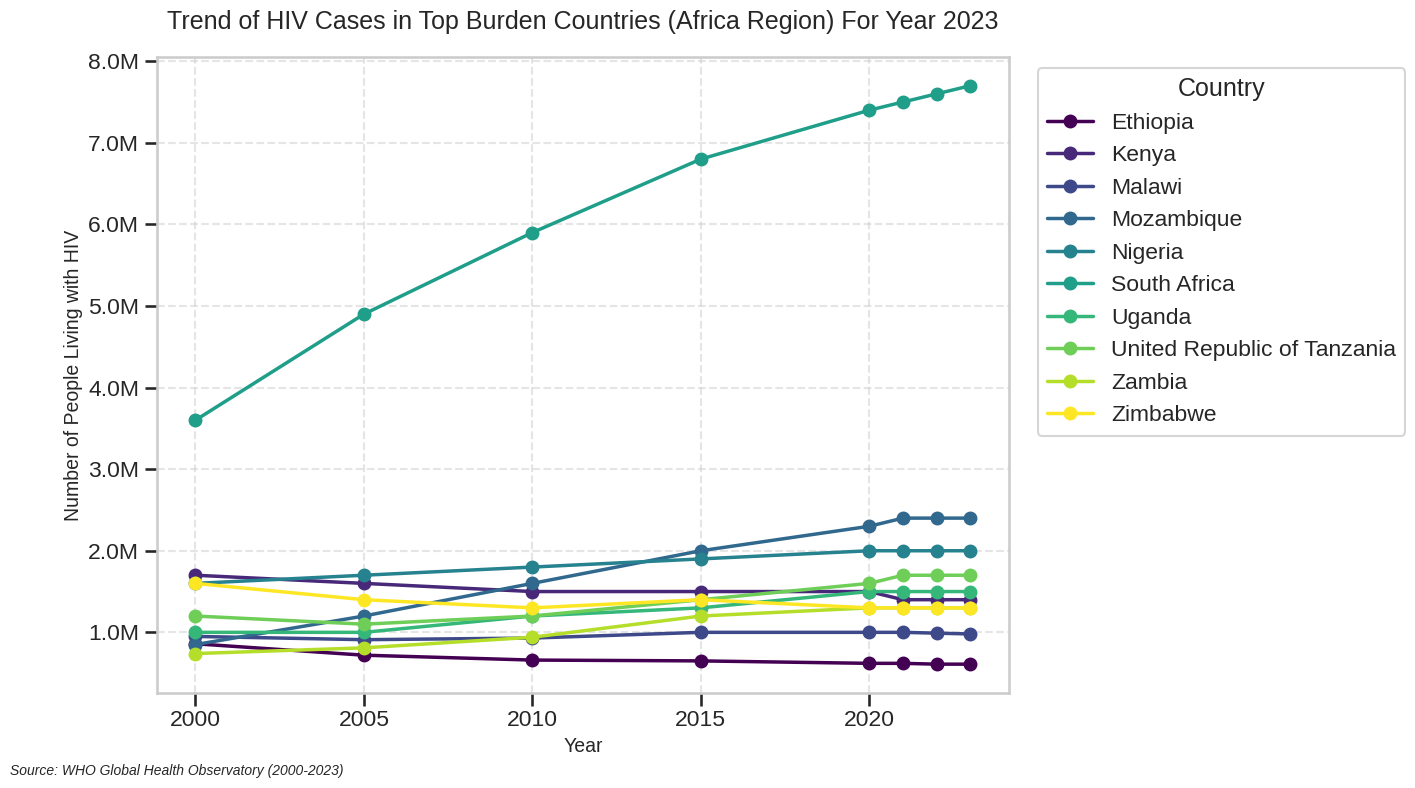

Americas (AMR)
 - Brazil: 100.00%




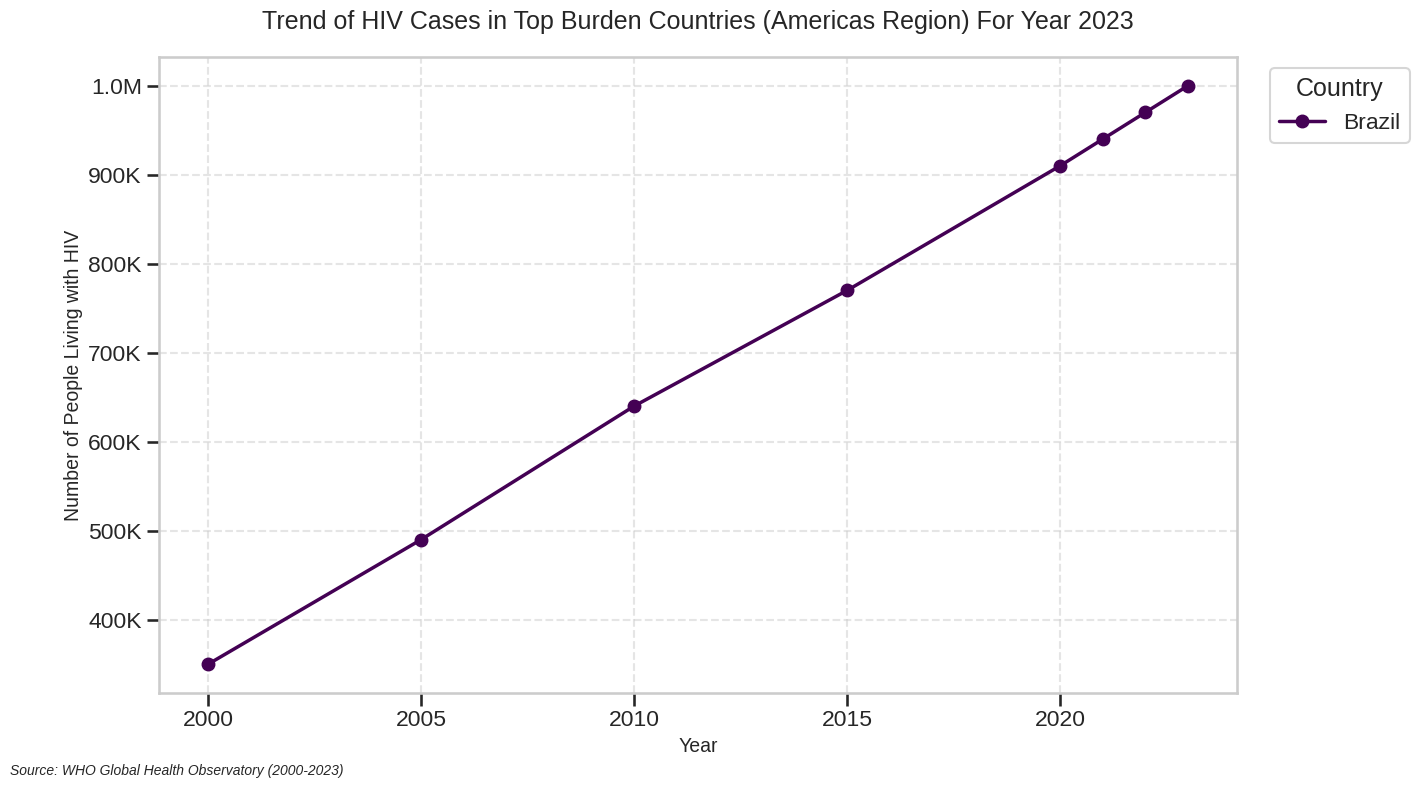

South-East Asia (SEAR)
 - India: 68.49%
 - Thailand: 15.89%
 - Indonesia: 15.62%




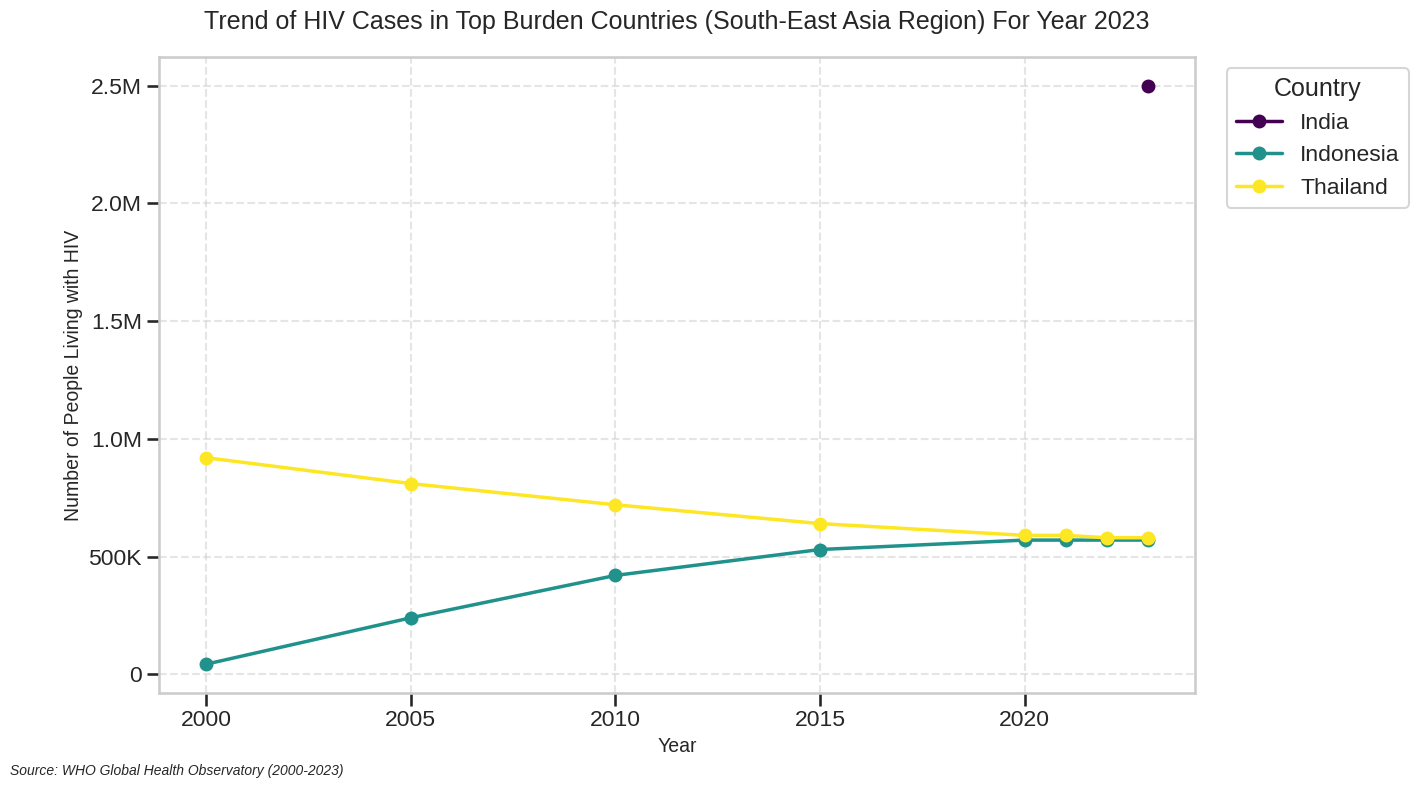

In [51]:
# Get list of WHO regions
who_regions_2023 = top_countries_data_2023['ParentLocationCode'].unique()



# Loop through each region and generate a chart
for region_code in who_regions_2023:
    # Get name of region
    region_name = top_countries_data_2023[top_countries_data_2023['ParentLocationCode'] == region_code]['ParentLocation'].iloc[0]
    
    # Filter for only this region
    region_data = top_countries_data_2023[top_countries_data_2023['ParentLocationCode'] == region_code]

    # Filter for the most recent year
    recent_region_data = region_data[region_data['Period'] == most_recent_year].copy()

    # Calculate region total
    region_total = recent_region_data['NumericValue'].sum()

    # Calculate percentage per country
    recent_region_data['PercentOfRegion'] = (recent_region_data['NumericValue'] / region_total) * 100

    # Sort by percentage
    sorted_region = recent_region_data.sort_values('PercentOfRegion', ascending=False)

    # Print region and country percentages
    print(f"{region_name} ({region_code})")
    for _, row in sorted_region.iterrows():
        country = row['Location']
        pct = row['PercentOfRegion']
        print(f" - {country}: {pct:.2f}%")
    print("\n")

    # Pivot table: Year vs Country values
    timeline_data = region_data.pivot_table(
        index='Period',  # or 'Year' if that's your column
        columns='Location',
        values='NumericValue',
        aggfunc='sum'
    )

    # Sort years
    timeline_data = timeline_data.sort_index()

    # Setup plot
    fig, ax = plt.subplots(figsize=(14, 8))
    colors = plt.cm.viridis(np.linspace(0, 1, len(timeline_data.columns)))

    for i, country in enumerate(timeline_data.columns):
        ax.plot(
            timeline_data.index,
            timeline_data[country],
            label=country,
            color=colors[i],
            linewidth=2.5,
            marker='o'
        )

    ax.set_title(f'Trend of HIV Cases in Top Burden Countries ({region_name} Region) For Year 2023', fontsize=18, pad=20)
    ax.set_xlabel('Year', fontsize=14)
    ax.set_ylabel('Number of People Living with HIV', fontsize=14)
    ax.yaxis.set_major_formatter(FuncFormatter(format_number))
    ax.grid(True, linestyle='--', alpha=0.5)

    # Legend formatting
    ax.legend(title="Country", bbox_to_anchor=(1.02, 1), loc='upper left', frameon=True)

    # Source + annotation
    plt.figtext(0.1, 0.01, 'Source: WHO Global Health Observatory (2000-2023)', ha='center', fontsize=10, style='italic')

    plt.tight_layout()
    plt.show();

## **QUESTION 1.3: You have also been provided with World Bank data on the multidimensional poverty headcount ratio, which includes factors such as income, educational attainment, school enrolment, electricity access, sanitation and drinking water. We would like you to merge this dataset with the HIV data above and analyze the relationship between people living with HIV and multidimensional poverty, and the individual factors that contribute to the ratio. Remember to account for the random effects (country, year).**

#### **Preparing the HIV data**

In [52]:
hiv_merged.head()

,IndicatorCode,Indicator,ValueType,ParentLocationCode,ParentLocation,Location type,SpatialDimValueCode,Location,Period type,Period,Value,NumericValue,GlobalTotal,PercentOfGlobalTotal
0,HIV_0000000001,Estimated number of people (all ages) living w...,numeric,AFR,Africa,Country,AGO,Angola,Year,2023,320 000 [280 000 - 380 000],320000,33933990,0.943007
1,HIV_0000000001,Estimated number of people (all ages) living w...,numeric,AFR,Africa,Country,AGO,Angola,Year,2022,320 000 [280 000 - 380 000],320000,31198310,1.025697
2,HIV_0000000001,Estimated number of people (all ages) living w...,numeric,AFR,Africa,Country,AGO,Angola,Year,2021,320 000 [280 000 - 380 000],320000,31314230,1.021900
3,HIV_0000000001,Estimated number of people (all ages) living w...,numeric,AFR,Africa,Country,AGO,Angola,Year,2020,320 000 [280 000 - 370 000],320000,31016150,1.031721
4,HIV_0000000001,Estimated number of people (all ages) living w...,numeric,AFR,Africa,Country,AGO,Angola,Year,2015,300 000 [260 000 - 350 000],300000,28925850,1.037135


In [53]:
hiv_merged = hiv_merged.rename(columns={
    'SpatialDimValueCode': 'CountryCode',
    'Location': 'Country',
    'Period': 'Year',
    'NumericValue': 'PLHIV' #PERSONS LIVING WITH HIV
})

In [54]:
# Create a pivot table with countries as rows and years as columns
hiv = hiv_merged[["CountryCode","Country","Year","PLHIV"]]

In [55]:
hiv.head()

,CountryCode,Country,Year,PLHIV
0,AGO,Angola,2023,320000
1,AGO,Angola,2022,320000
2,AGO,Angola,2021,320000
3,AGO,Angola,2020,320000
4,AGO,Angola,2015,300000


In [56]:
hiv.isnull().sum()

CountryCode    0
Country        0
Year           0
PLHIV          0
dtype: int64

#### **Preparing WorldBank Data on Multidimensional Poverty**

In [57]:
# Load WorldBank Poverty Dataset

wb_poverty_df = pd.read_excel("multidimensional_poverty.xlsx")
wb_poverty_df.head(10)

,"Individuals in households deprived in each indicator, 110 economies, circa year 2021 (2018-2023)\nDate: October 2024",Unnamed: 1,Unnamed: 2,Unnamed: 3,Unnamed: 4,Unnamed: 5,Unnamed: 6,Unnamed: 7,Unnamed: 8,Unnamed: 9,Unnamed: 10,Unnamed: 11,Unnamed: 12,Unnamed: 13,Unnamed: 14,Unnamed: 15
0,Region,Country code,Economy,Reporting year,Survey name,Survey year,Survey coverage,Welfare type,Survey comparability,Deprivation rate (share of population),NaN,NaN,NaN,NaN,NaN,Multidimensional poverty headcount ratio (%)
1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Monetary (%),Educational attainment (%),Educational enrollment (%),Electricity (%),Sanitation (%),Drinking water (%),NaN
2,SSA,AGO,Angola,2018,IDREA,2018,N,c,2,31.122005,29.753423,27.44306,52.639532,53.637516,32.106507,47.203606
3,ECA,ALB,Albania,2012,HBS,2018,N,c,1,0.048107,0.19238,-,0.06025,6.579772,9.594966,0.293161
4,LAC,ARG,Argentina,2010,EPHC-S2,2021,U,i,3,0.894218,1.08532,0.731351,0,0.257453,0.364048,0.906573
5,ECA,ARM,Armenia,2010,ILCS,2021,N,c,1,0.523521,0,1.793004,0,0.397725,0.660082,0.523521
6,EAP,AUS,Australia,2010,SIH-LIS,2018,N,I,3,0.51688,1.71188,-,0,0,-,2.21577
7,ECA,AUT,Austria,2009,EU-SILC,2022,N,i,2,0.485822,0.176422,-,0,-,0,0.662245
8,SSA,BDI,Burundi,2013,EICVMB,2020,N,c,1,62.065762,44.881231,34.211618,90.568537,91.007495,12.021417,79.209852
9,ECA,BEL,Belgium,2009,EU-SILC,2022,N,i,2,0.029965,0.64869,-,0,-,0,0.679716


#### **Clean poverty data**

In [58]:
# Identify header rows and set proper column names
# First two rows contain multi-level headers: row0 for names, row1 for subfields

header_0 = wb_poverty_df.iloc[0]
header_1 = wb_poverty_df.iloc[1]

In [59]:
# Build final column names by combining header_0 and header_1

combined_cols = []
for h0, h1 in zip(header_0, header_1):
    if pd.isna(h1):
        combined_cols.append(str(h0).strip())
    else:
        combined_cols.append(f"{h1.strip()}")

In [60]:
# Assign columns and drop header rows

poverty = wb_poverty_df.iloc[2:].copy()
poverty.columns = combined_cols

In [61]:
poverty.head()

,Region,Country code,Economy,Reporting year,Survey name,Survey year,Survey coverage,Welfare type,Survey comparability,Monetary (%),Educational attainment (%),Educational enrollment (%),Electricity (%),Sanitation (%),Drinking water (%),Multidimensional poverty headcount ratio (%)
2,SSA,AGO,Angola,2018,IDREA,2018,N,c,2,31.122005,29.753423,27.44306,52.639532,53.637516,32.106507,47.203606
3,ECA,ALB,Albania,2012,HBS,2018,N,c,1,0.048107,0.19238,-,0.06025,6.579772,9.594966,0.293161
4,LAC,ARG,Argentina,2010,EPHC-S2,2021,U,i,3,0.894218,1.08532,0.731351,0,0.257453,0.364048,0.906573
5,ECA,ARM,Armenia,2010,ILCS,2021,N,c,1,0.523521,0,1.793004,0,0.397725,0.660082,0.523521
6,EAP,AUS,Australia,2010,SIH-LIS,2018,N,I,3,0.51688,1.71188,-,0,0,-,2.21577


In [62]:
# Select and convert numeric columns

keep_cols = ['Country code','Reporting year','Monetary (%)', 'Educational attainment (%)',
             'Educational enrollment (%)','Electricity (%)','Sanitation (%)','Drinking water (%)','Multidimensional poverty headcount ratio (%)']
poverty = poverty[keep_cols].rename(columns={
    'Country code':'CountryCode',
    'Reporting year':'Year',
    'Monetary (%)':'Monetary',
    'Educational attainment (%)':'EducationalAttainment',
    'Educational enrollment (%)':'EducationalEnrollment',
    'Electricity (%)':'Electricity',
    'Sanitation (%)':'Sanitation',
    'Drinking water (%)':'DrinkingWater',
    'Multidimensional poverty headcount ratio (%)':'MPI'
})

# Convert datatypes
def to_numeric(col):
    poverty[col] = pd.to_numeric(poverty[col], errors='coerce')
for col in ['Year','Monetary','EducationalAttainment','EducationalEnrollment','Electricity','Sanitation','DrinkingWater','MPI']:
    to_numeric(col)

#### **Merging WorldBank poverty data and HIV data on country code and year**

In [63]:
# Merge HIV and poverty on CountryCode & Year

data = pd.merge(
    hiv[['CountryCode','Country','Year','PLHIV']],
    poverty[['CountryCode','Year','MPI','Monetary','EducationalAttainment',
             'EducationalEnrollment','Electricity','Sanitation','DrinkingWater']],
    on=['CountryCode','Year'],
    how='inner'
)
print(f"Merged dataset dimensions: {data.shape}")

Merged dataset dimensions: (41, 11)


In [64]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 41 entries, 0 to 40
Data columns (total 11 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   CountryCode            41 non-null     object 
 1   Country                41 non-null     object 
 2   Year                   41 non-null     int64  
 3   PLHIV                  41 non-null     int64  
 4   MPI                    41 non-null     float64
 5   Monetary               41 non-null     float64
 6   EducationalAttainment  41 non-null     float64
 7   EducationalEnrollment  34 non-null     float64
 8   Electricity            40 non-null     float64
 9   Sanitation             40 non-null     float64
 10  DrinkingWater          37 non-null     float64
dtypes: float64(7), int64(2), object(2)
memory usage: 3.6+ KB


In [65]:
# Drop rows with missing values in important predictors

data = data.dropna(subset=['EducationalEnrollment', 'Electricity', 
                           'Sanitation', 'DrinkingWater'])

data.isnull().sum()

CountryCode              0
Country                  0
Year                     0
PLHIV                    0
MPI                      0
Monetary                 0
EducationalAttainment    0
EducationalEnrollment    0
Electricity              0
Sanitation               0
DrinkingWater            0
dtype: int64

In [66]:
# Fit mixed-effects model accounting for random effects of country and year
#  - Random intercept for CountryCode (groups)
#  - Variance component (random intercept) for each Year

formula = (
    'PLHIV ~ MPI + Monetary + EducationalAttainment + '
    'EducationalEnrollment + Electricity + Sanitation + DrinkingWater'
)
md = smf.mixedlm(
    formula,
    data,
    groups=data['CountryCode'],
    vc_formula={'Year': '0 + C(Year)'}
)
mdf = md.fit(reml=False)
print(mdf.summary())

                     Mixed Linear Model Regression Results
Model:                   MixedLM       Dependent Variable:       PLHIV          
No. Observations:        32            Method:                   ML             
No. Groups:              32            Scale:                    6648443466.0972
Min. group size:         1             Log-Likelihood:           -418.3788      
Max. group size:         1             Converged:                Yes            
Mean group size:         1.0                                                    
--------------------------------------------------------------------------------
                          Coef.       Std.Err.   z    P>|z|   [0.025     0.975] 
--------------------------------------------------------------------------------
Intercept                 -26952.246 33512.488 -0.804 0.421 -92635.515 38731.024
MPI                         4892.750  4865.140  1.006 0.315  -4642.748 14428.248
Monetary                   15906.202  6293.498  2.

In [67]:
# Extract and display fixed-effect coefficients

fe = mdf.fe_params
se = mdf.bse_fe
p = mdf.pvalues
coeffs = pd.DataFrame({'Estimate': fe, 'StdErr': se, 'p-value': p})
print('\nFixed-effects coefficients:')
print(coeffs)


Fixed-effects coefficients:
                           Estimate        StdErr       p-value
DrinkingWater          23606.524441   3733.297241  2.561395e-10
EducationalAttainment   8916.144749   3425.136116  9.237140e-03
EducationalEnrollment -16150.758735   3268.086472  7.734034e-07
Electricity           -10804.003921   3618.762281  2.830668e-03
Intercept             -26952.245722  33512.487878  4.212556e-01
MPI                     4892.749802   4865.139535  3.145719e-01
Monetary               15906.201973   6293.498006  1.149098e-02
Sanitation             -4286.689845   2259.234379  5.777408e-02
Year Var                        NaN           NaN           NaN


#### **Visualizing The Fixed Effects Coefficients**

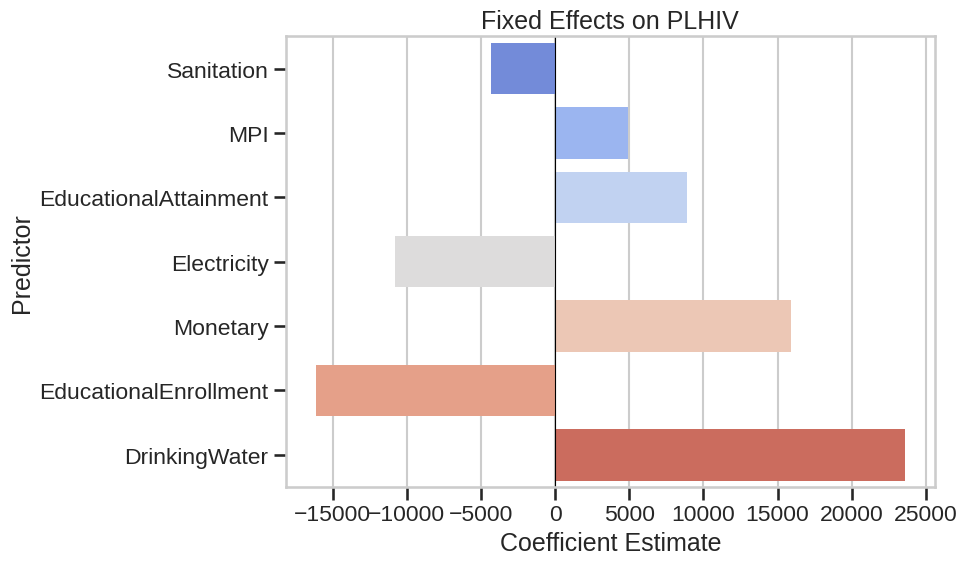

In [68]:
# Visualize fixed effects coefficients


# Filter only the fixed effects we care about (excluding Intercept and Year Var)
coeffs_plot = coeffs.drop(index=['Intercept'])
coeffs_plot = coeffs_plot.dropna()  # Drop any NaNs (like Year Var)

# Sort by absolute size of estimate for nicer ordering
coeffs_plot['abs_estimate'] = coeffs_plot['Estimate'].abs()
coeffs_plot = coeffs_plot.sort_values('abs_estimate', ascending=True)

# Create the barplot
plt.figure(figsize=(10,6))
sns.barplot(
    x='Estimate',
    y=coeffs_plot.index,
    data=coeffs_plot,
    palette='coolwarm',
    orient='h'
)
plt.axvline(0, color='black', linewidth=0.8)  # Add a vertical line at zero
plt.title('Fixed Effects on PLHIV')
plt.xlabel('Coefficient Estimate')
plt.ylabel('Predictor')
plt.tight_layout()
plt.show();


## **FINDINGS**

After merging HIV prevalence data with multidimensional poverty indicators, our mixed-effects model—accounting for random effects by country and year—reveals the following:

- Poor access to **safe drinking water** is the strongest positive predictor of HIV burden, with an estimated coefficient of **+23,607** (*p* < 0.001).
- **Educational enrollment** shows a strong negative association (**-16,151**, *p* < 0.001), indicating that higher school enrollment correlates with fewer people living with HIV.
- **Monetary poverty** (**+15,906**, *p* = 0.011) and lower **educational attainment** (**+8,916**, *p* = 0.009) are also significant positive factors.
- Reduced **electricity access** (**-10,804**, *p* = 0.003) is associated with fewer people living with HIV.
- **Sanitation** shows a marginal negative effect (**-4,287**, *p* = 0.058).
- The overall **Multidimensional Poverty Index (MPI)** itself was **not statistically significant** (*p* = 0.315).

These results highlight that improvements in **water access**, **education quality and enrollment**, **energy infrastructure**, and **income support programs** are critical to reducing HIV prevalence in high-burden countries.


# **PROJECT 2**

## **Question 2: You have been provided with data on the under-five mortality rate and neonatal mortality rate for the African region, which has been downloaded from the UN Inter-agency Group for Child Mortality Estimation. Your task is to:**

- Filter data for the eight countries belonging to the East African Community (list here: https://www.eac.int/overview-of-eac)
- Visualize the latest estimate of each indicator at the country level using shapefiles, which can be downloaded from www.gadm.org.
- Show the average trends in the mortality rates over time (plot the average trend line and add the points in the graphic for the country level estimates for each indicator. Expectation: two plots).
- Based on your visualizations, identify the countries with the highest under-five mortality rates in East Africa and the highest neonatal mortality.

### **Question 2.1: Filter data for the eight countries belonging to the East African Community**

In [69]:
# Loading the dataset

mortality_data = pd.read_csv('dataset_datascience.csv', encoding='latin1')
mortality_data.head()

,REF_AREA,Geographic area,Regional group,Indicator,Sex,Wealth Quintile,Series Name,Series Year,Reference Date,Observation Value,...,Country notes,Observation Status,Unit of measure,Series Type,Series Category,Series Method,Age Group of Women,Time Since First Birth,Definition,Interval
0,AFG,Afghanistan,NaN,Neonatal mortality rate,Total,Total,Afghanistan Health Survey 2018 (Direct),2018,1995.5,47.869030,...,NaN,Excluded from IGME,"Deaths per 1,000 live births",Direct,Others,Survey/Census with Full Birth Histories,NaN,NaN,NaN,5.0
1,AFG,Afghanistan,NaN,Neonatal mortality rate,Total,Total,Afghanistan Health Survey 2018 (Direct),2018,2000.5,35.349317,...,NaN,Excluded from IGME,"Deaths per 1,000 live births",Direct,Others,Survey/Census with Full Birth Histories,NaN,NaN,NaN,5.0
2,AFG,Afghanistan,NaN,Neonatal mortality rate,Total,Total,Afghanistan Health Survey 2018 (Direct),2018,2005.5,27.699219,...,NaN,Excluded from IGME,"Deaths per 1,000 live births",Direct,Others,Survey/Census with Full Birth Histories,NaN,NaN,NaN,5.0
3,AFG,Afghanistan,NaN,Neonatal mortality rate,Total,Total,Afghanistan Health Survey 2018 (Direct),2018,2010.5,21.056003,...,NaN,Excluded from IGME,"Deaths per 1,000 live births",Direct,Others,Survey/Census with Full Birth Histories,NaN,NaN,NaN,5.0
4,AFG,Afghanistan,NaN,Neonatal mortality rate,Total,Total,Afghanistan Health Survey 2018 (Direct),2018,2015.5,20.167379,...,NaN,Excluded from IGME,"Deaths per 1,000 live births",Direct,Others,Survey/Census with Full Birth Histories,NaN,NaN,NaN,5.0


In [70]:
# Define List of East African Community countries

eac_countries = [
    'Burundi', 'Kenya', 'Rwanda', 'South Sudan', 
    'Tanzania', 'Uganda', 'Democratic Republic of the Congo', 'Somalia'
]

In [71]:
# Filter data for EAC countries

eac_data = mortality_data[mortality_data['Geographic area'].isin(eac_countries)]
eac_data.head()

,REF_AREA,Geographic area,Regional group,Indicator,Sex,Wealth Quintile,Series Name,Series Year,Reference Date,Observation Value,...,Country notes,Observation Status,Unit of measure,Series Type,Series Category,Series Method,Age Group of Women,Time Since First Birth,Definition,Interval
6387,BDI,Burundi,NaN,Neonatal mortality rate,Total,Total,Demographic and Health Survey 2016-2017 (Direct),2016-2017,1993.5,36.41348,...,NaN,Excluded from IGME,"Deaths per 1,000 live births",Direct,DHS,Survey/Census with Full Birth Histories,NaN,NaN,NaN,5.0
6388,BDI,Burundi,NaN,Neonatal mortality rate,Total,Total,Demographic and Health Survey 2016-2017 (Direct),2016-2017,1998.5,41.25996,...,NaN,Included in IGME,"Deaths per 1,000 live births",Direct,DHS,Survey/Census with Full Birth Histories,NaN,NaN,NaN,5.0
6389,BDI,Burundi,NaN,Neonatal mortality rate,Total,Total,Demographic and Health Survey 2016-2017 (Direct),2016-2017,2003.5,32.83915,...,NaN,Included in IGME,"Deaths per 1,000 live births",Direct,DHS,Survey/Census with Full Birth Histories,NaN,NaN,NaN,5.0
6390,BDI,Burundi,NaN,Neonatal mortality rate,Total,Total,Demographic and Health Survey 2016-2017 (Direct),2016-2017,2008.5,28.46557,...,NaN,Included in IGME,"Deaths per 1,000 live births",Direct,DHS,Survey/Census with Full Birth Histories,NaN,NaN,NaN,5.0
6391,BDI,Burundi,NaN,Neonatal mortality rate,Total,Total,Demographic and Health Survey 2016-2017 (Direct),2016-2017,2013.5,23.70623,...,NaN,Included in IGME,"Deaths per 1,000 live births",Direct,DHS,Survey/Census with Full Birth Histories,NaN,NaN,NaN,5.0


### **Understanding the Data Structure**
The provided dataset contains detailed mortality information for Countries with:

- Neonatal mortality rates (deaths within the first 28 days of life)
- Under-five mortality rates (deaths before age 5)
- Different survey sources and time periods
- Data broken down by gender, region, and other variables

In [72]:
eac_data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 4861 entries, 6387 to 113639
Data columns (total 23 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   REF_AREA                4861 non-null   object 
 1   Geographic area         4861 non-null   object 
 2   Regional group          0 non-null      object 
 3   Indicator               4861 non-null   object 
 4   Sex                     4861 non-null   object 
 5   Wealth Quintile         4861 non-null   object 
 6   Series Name             4861 non-null   object 
 7   Series Year             4861 non-null   object 
 8   Reference Date          4861 non-null   float64
 9   Observation Value       4861 non-null   float64
 10  Lower Bound             2867 non-null   float64
 11  Upper Bound             2867 non-null   float64
 12  Standard Error          1537 non-null   float64
 13  Country notes           0 non-null      object 
 14  Observation Status      4861 non-null   

In [73]:
eac_data['Geographic area'].value_counts()

Geographic area
Rwanda                              976
Kenya                               972
Uganda                              934
Burundi                             585
Democratic Republic of the Congo    508
South Sudan                         506
Somalia                             380
Name: count, dtype: int64

In [74]:
# Viewing Data Sources

eac_data['Series Name'].value_counts()

Series Name
UN IGME estimate                               2867
Demographic and Health Survey 2014 (Direct)      45
Demographic and Health Survey 2000 (Direct)      42
Demographic and Health Survey 2005 (Direct)      42
Demographic and Health Survey 2006 (Direct)      42
                                               ... 
Census 1991 (Direct)                              1
Census 2002 (Direct)                              1
Census 1993 (Household Deaths)                    1
Mortality Assessment Survey 2015 (Direct)         1
Census 2012 (Household Deaths)                    1
Name: count, Length: 128, dtype: int64

#### **Data Quality Considerations**
From the cell above data, I noticed there are multiple data sources for each country:

- Direct surveys (MICS, DHS, etc.)
- Adjusted survey data
- UN IGME estimates

For consistency, focus primarily on the "UN IGME estimate" rows which represent the official UN estimates that have been harmonized across countries. These have the note "Normal value" in the "Observation Status" column.

In [75]:
# Filter for UN IGME estimates only (most reliable source)

eac_estimates = eac_data[eac_data['Series Name'] == 'UN IGME estimate']

In [76]:
# Separate data for the two indicators i.e neonatal and underfive rates

neonatal_data = eac_estimates[eac_estimates['Indicator'] == 'Neonatal mortality rate']
underfive_data = eac_estimates[eac_estimates['Indicator'] == 'Under-five mortality rate']

### **Question 2.2: Visualize the latest estimate of each indicator at the country level using shapefiles**

In [77]:
# Creating Map Visualizations
# Load shapefile for East African Countries

kenya_map = gpd.read_file('shapefiles/gadm41_KEN_2.shp')
uganda_map = gpd.read_file('shapefiles/gadm41_UGA_2.shp')
tanzania_map = gpd.read_file('shapefiles/gadm41_TZA_2.shp')
rwanda_map = gpd.read_file('shapefiles/gadm41_RWA_2.shp')
burundi_map = gpd.read_file('shapefiles/gadm41_BDI_2.shp')
somalia_map = gpd.read_file('shapefiles/gadm41_SOM_2.shp')
congo_map = gpd.read_file('shapefiles/gadm41_COG_2.shp')
south_sudan_map = gpd.read_file('shapefiles/gadm41_SSD_2.shp')

In [78]:
# Add country name column to each GeoDataFrame

kenya_map['NAME_0'] = 'Kenya'
uganda_map['NAME_0'] = 'Uganda'
tanzania_map['NAME_0'] = 'Tanzania'
rwanda_map['NAME_0'] = 'Rwanda'
burundi_map['NAME_0'] = 'Burundi'
somalia_map['NAME_0'] = 'Somalia'
congo_map['NAME_0'] = 'Democratic Republic of the Congo'
south_sudan_map['NAME_0'] = 'South Sudan'

In [79]:
# Dissolve each country's administrative boundaries to get country outlines

kenya_outline = kenya_map.dissolve(by='NAME_0')
uganda_outline = uganda_map.dissolve(by='NAME_0')
tanzania_outline = tanzania_map.dissolve(by='NAME_0')
rwanda_outline = rwanda_map.dissolve(by='NAME_0')
burundi_outline = burundi_map.dissolve(by='NAME_0')
somalia_outline = somalia_map.dissolve(by='NAME_0')
congo_outline = congo_map.dissolve(by='NAME_0')
south_sudan_outline = south_sudan_map.dissolve(by='NAME_0')

In [80]:
# Combine all country outlines into a single GeoDataFrame

eac_map = pd.concat([kenya_outline, uganda_outline, tanzania_outline, rwanda_outline, 
                     burundi_outline, somalia_outline, congo_outline, south_sudan_outline])

# Reset index to make NAME_0 a regular column again

eac_map = eac_map.reset_index()

In [81]:
# Get latest estimates for each country

latest_year = eac_estimates['Reference Date'].max()
latest_estimates = eac_estimates[eac_estimates['Reference Date'] == latest_year]

In [82]:
# Create separate dataframes for each indicator's latest values

latest_neonatal = latest_estimates[latest_estimates['Indicator'] == 'Neonatal mortality rate']
latest_underfive = latest_estimates[latest_estimates['Indicator'] == 'Under-five mortality rate']

In [83]:
# Merge geographical data with mortality data

neonatal_map = eac_map.merge(latest_neonatal, left_on='NAME_0', right_on='Geographic area')
underfive_map = eac_map.merge(latest_underfive, left_on='NAME_0', right_on='Geographic area')

#### **Visualize Neonatal Mortality and Underfive Mortality**

#### Map 1: Neonatal mortality

<Figure size 1200x1000 with 0 Axes>

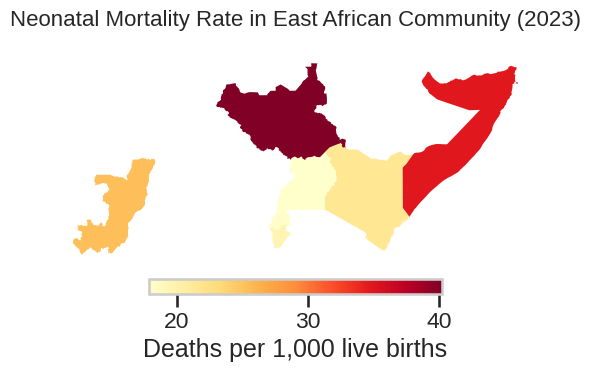

In [84]:
# Map 1: Neonatal mortality

plt.figure(figsize=(12, 10))
ax = neonatal_map.plot(column='Observation Value', 
                      cmap='YlOrRd', 
                      legend=True,
                      legend_kwds={'label': 'Deaths per 1,000 live births',
                                  'orientation': 'horizontal',
                                  'shrink': 0.6,
                                  'pad': 0.05})
plt.title('Neonatal Mortality Rate in East African Community (2023)', 
         fontsize=16, 
         pad=20)  # Add padding between title and map
plt.axis('off')
plt.tight_layout(pad=3.0)  # Add padding around the entire plot
plt.show();

#### Map 2: Under-five mortality

<Figure size 1200x1000 with 0 Axes>

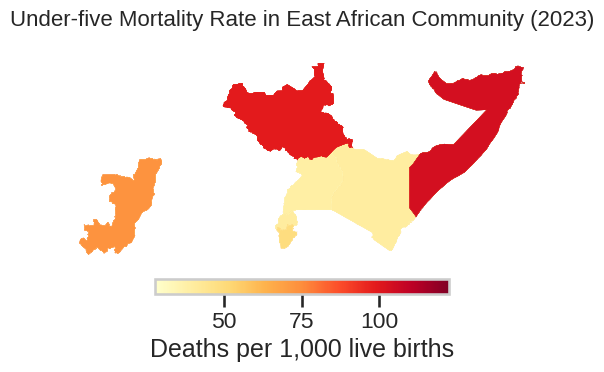

In [85]:
# Map 2: Under-five mortality

plt.figure(figsize=(12, 10))
ax = underfive_map.plot(column='Observation Value', 
                       cmap='YlOrRd', 
                       legend=True,
                       legend_kwds={'label': 'Deaths per 1,000 live births',
                                   'orientation': 'horizontal',
                                   'shrink': 0.6,
                                   'pad': 0.05})
plt.title('Under-five Mortality Rate in East African Community (2023)', 
         fontsize=16, 
         pad=20)  # Add padding between title and map
plt.axis('off')
plt.tight_layout(pad=3.0)  # Add padding around the entire plot
plt.show();

### **Question 2.3: Show the average trends in the mortality rates over time (plot the average trend line and add the points in the graphic for the country level estimates for each indicator. Expectation: two plots).**

#### **Visualizing Trends Over Time**

In [86]:
# Prepare time series data - average across countries by year

neonatal_time = neonatal_data.groupby('Reference Date')['Observation Value'].mean().reset_index()
underfive_time = underfive_data.groupby('Reference Date')['Observation Value'].mean().reset_index()

In [87]:
# Check for duplicates

print("Checking for duplicate records in under-five data:")
print(underfive_data.duplicated().sum(), "duplicate rows found")

Checking for duplicate records in under-five data:
0 duplicate rows found


In [88]:
# Check if there are multiple entries per country per year

duplicate_country_years = underfive_data.groupby(['Geographic area', 'Reference Date']).size()
print("\nCountries with multiple entries per year:")
print(duplicate_country_years[duplicate_country_years > 1])


Countries with multiple entries per year:
Geographic area  Reference Date
Burundi          1965.5            3
                 1966.5            3
                 1967.5            3
                 1968.5            3
                 1969.5            3
                                  ..
Uganda           2019.5            8
                 2020.5            8
                 2021.5            8
                 2022.5            8
                 2023.5            8
Length: 435, dtype: int64


In [89]:
# Examine a few examples of multiple entries for the same country and year

for (country, year), count in duplicate_country_years[duplicate_country_years > 1].items():
    print(f"\nMultiple entries for {country} in {year} (count: {count}):")
    print(underfive_data[(underfive_data['Geographic area'] == country) & 
                        (underfive_data['Reference Date'] == year)])


Multiple entries for Burundi in 1965.5 (count: 3):
     REF_AREA Geographic area Regional group                  Indicator  \
6495      BDI         Burundi            NaN  Under-five mortality rate   
6587      BDI         Burundi            NaN  Under-five mortality rate   
6913      BDI         Burundi            NaN  Under-five mortality rate   

         Sex Wealth Quintile       Series Name Series Year  Reference Date  \
6495  Female           Total  UN IGME estimate        2023          1965.5   
6587    Male           Total  UN IGME estimate        2023          1965.5   
6913   Total           Total  UN IGME estimate        2023          1965.5   

      Observation Value  ...  Country notes  Observation Status  \
6495         238.206731  ...            NaN        Normal value   
6587         248.443868  ...            NaN        Normal value   
6913         243.473700  ...            NaN        Normal value   

                   Unit of measure Series Type Series Category Se

#### Filter to keep only the "Total" sex category and "Total" Wealth quintile category to prevent overlapping scatter points with multiple data points for the same countries in the same years.


In [90]:
# Filter to keep only the "Total" sex category and "Total" Wealth quintile category

underfive_data_total = underfive_data[
    (underfive_data['Sex'] == 'Total') & (underfive_data['Wealth Quintile'] == 'Total')
]

#### Plot 1: Neonatal mortality trends

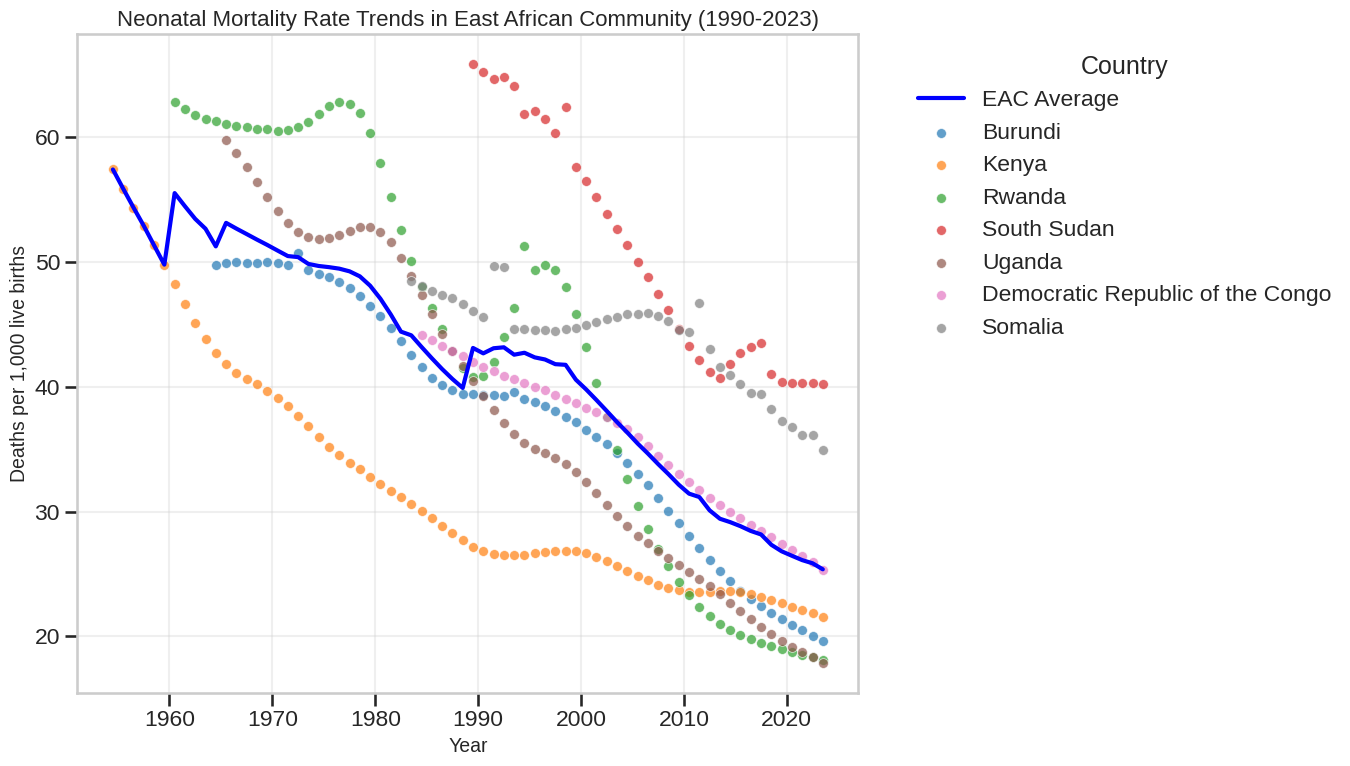

In [91]:
# Plot 1: Neonatal mortality trends

plt.figure(figsize=(14, 8))
sns.lineplot(data=neonatal_time, x='Reference Date', y='Observation Value', 
            color='blue', linewidth=3, label='EAC Average')

# Add individual country points
for country in eac_countries:
    country_data = neonatal_data[neonatal_data['Geographic area'] == country]
    sns.scatterplot(data=country_data, x='Reference Date', y='Observation Value', 
                   label=country, s=50, alpha=0.7)

plt.title('Neonatal Mortality Rate Trends in East African Community (1990-2023)', fontsize=16)
plt.xlabel('Year', fontsize=14)
plt.ylabel('Deaths per 1,000 live births', fontsize=14)
plt.grid(True, alpha=0.3)
plt.legend(title='Country', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show();

#### Plot 2: Under-five mortality trends

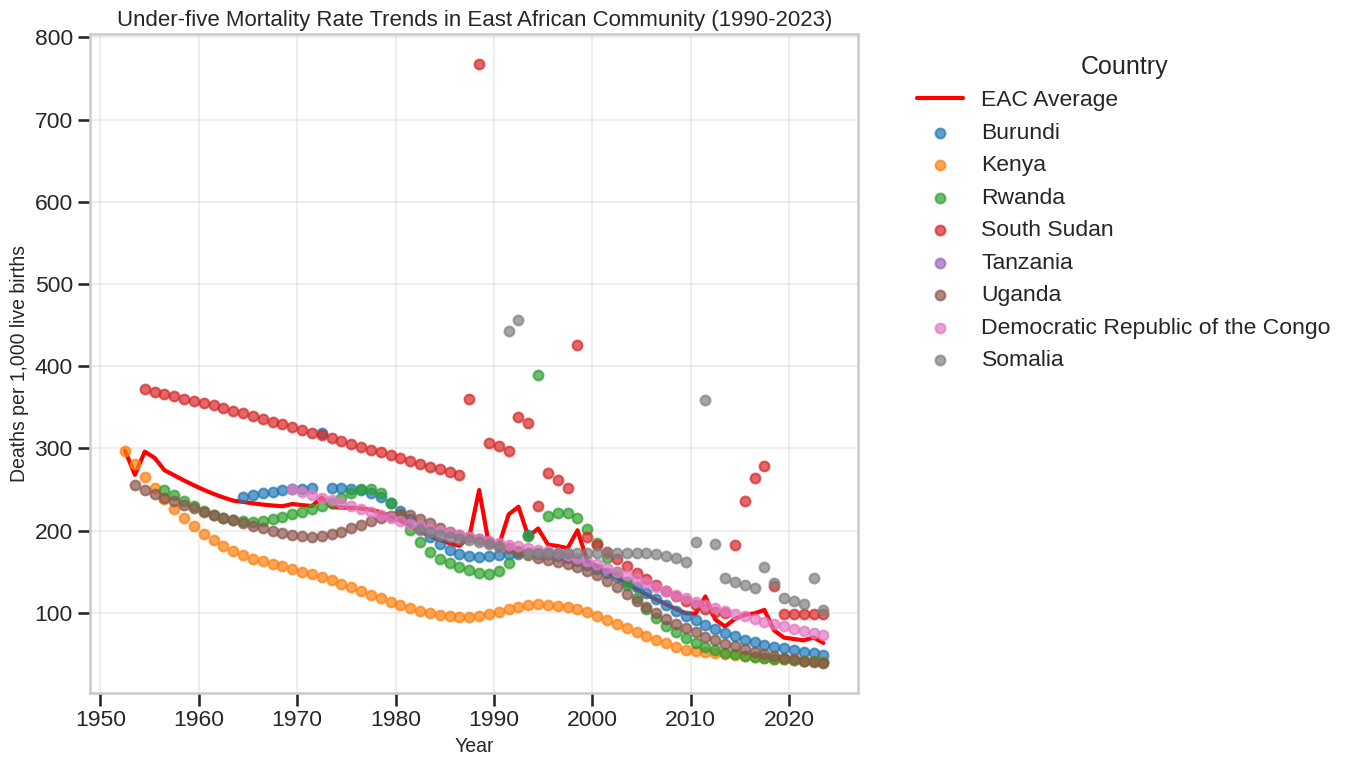

In [92]:
# Plot 2: Under-five mortality trends

# Plot with the filtered data

plt.figure(figsize=(14, 8))
sns.lineplot(
    # Recalculate the average using only the Total values
    data=underfive_data_total.groupby('Reference Date')['Observation Value'].mean().reset_index(), 
    x='Reference Date', 
    y='Observation Value', 
    color='red', 
    linewidth=3, 
    label='EAC Average'
)

# Add individual country points
for country in eac_countries:
    country_data = underfive_data_total[underfive_data_total['Geographic area'] == country]
    plt.scatter(
        country_data['Reference Date'],
        country_data['Observation Value'],
        label=country, 
        s=50, 
        alpha=0.7,
        zorder=3
    )

plt.title('Under-five Mortality Rate Trends in East African Community (1990-2023)', fontsize=16)
plt.xlabel('Year', fontsize=14)
plt.ylabel('Deaths per 1,000 live births', fontsize=14)
plt.grid(True, alpha=0.3)
plt.legend(title='Country', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show();

#### Identifying Countries with Highest Mortality Rates

In [93]:
# Get the latest year for each country AND indicator combination

latest_data = eac_estimates.loc[eac_estimates.groupby(['Geographic area', 'Indicator'])['Reference Date'].idxmax()]

In [94]:
# Sort countries by mortality rates

neonatal_ranking = latest_data[latest_data['Indicator'] == 'Neonatal mortality rate'].sort_values(
    by='Observation Value', ascending=False)
underfive_ranking = latest_data[latest_data['Indicator'] == 'Under-five mortality rate'].sort_values(
    by='Observation Value', ascending=False)

In [95]:
# Print results for neonatal mortality rates

print("Countries with highest neonatal mortality rates:")
print(neonatal_ranking[['Geographic area', 'Observation Value']].head())

Countries with highest neonatal mortality rates:
                        Geographic area  Observation Value
99212                       South Sudan          40.240552
98220                           Somalia          34.904816
21816  Democratic Republic of the Congo          25.346972
55255                             Kenya          21.513320
6461                            Burundi          19.603026


In [96]:
# Print results for under-five mortality rates

print("\nCountries with highest under-five mortality rates:")
print(underfive_ranking[['Geographic area', 'Observation Value']].head())


Countries with highest under-five mortality rates:
                        Geographic area  Observation Value
98267                           Somalia          98.091514
99293                       South Sudan          93.397061
21896  Democratic Republic of the Congo          67.624181
6553                            Burundi          45.025732
92630                            Rwanda          36.115174


#### Bar chart for neonatal mortality

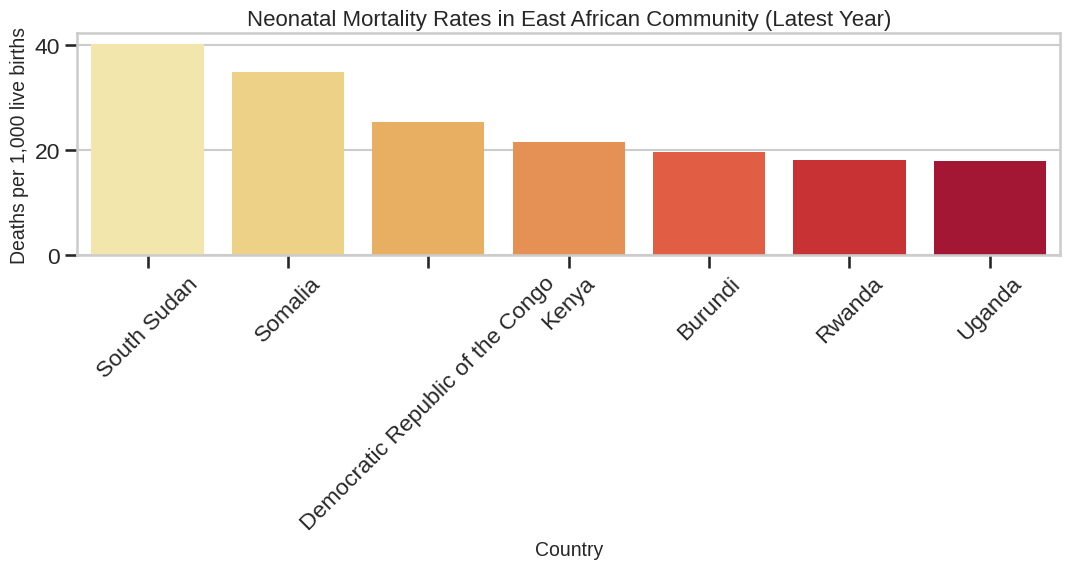

In [97]:
# Bar chart for neonatal mortality

plt.figure(figsize=(12, 7))
sns.barplot(data=neonatal_ranking, x='Geographic area', y='Observation Value', 
           palette='YlOrRd')
plt.title('Neonatal Mortality Rates in East African Community (Latest Year)', fontsize=16)
plt.xlabel('Country', fontsize=14)
plt.ylabel('Deaths per 1,000 live births', fontsize=14)
plt.tick_params(axis='x', rotation=45)
plt.tight_layout(pad=3.0)
plt.show();

#### Bar chart for under-five mortality

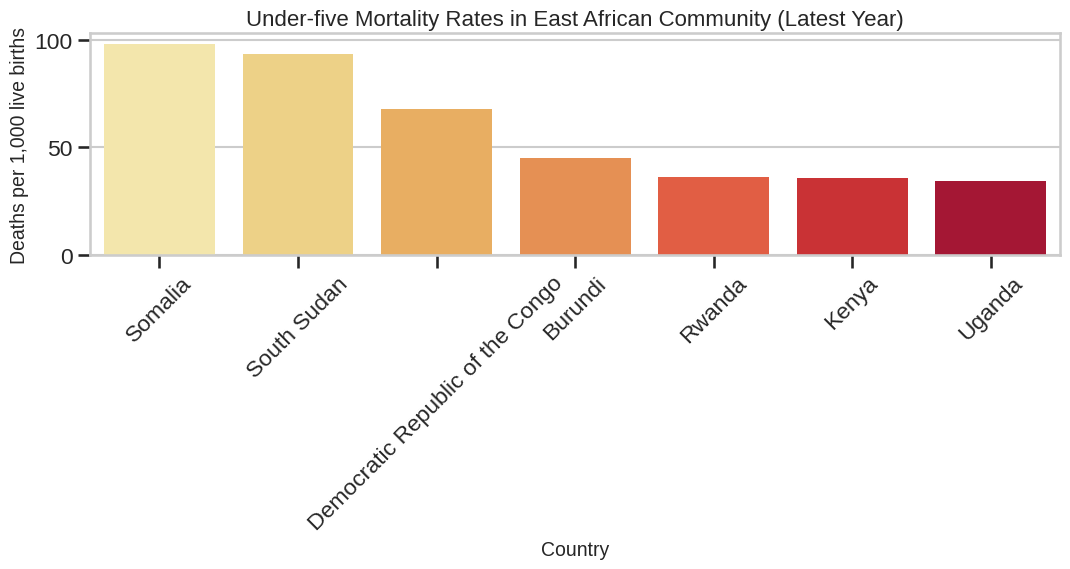

In [99]:
# Bar chart for under-five mortality

plt.figure(figsize=(12, 7))
sns.barplot(data=underfive_ranking, x='Geographic area', y='Observation Value', 
           palette='YlOrRd')
plt.title('Under-five Mortality Rates in East African Community (Latest Year)', fontsize=16)
plt.xlabel('Country', fontsize=14)
plt.ylabel('Deaths per 1,000 live births', fontsize=14)
plt.tick_params(axis='x', rotation=45)
plt.tight_layout(pad=3.0)
plt.show();

### **Question 2.4: Based on your visualizations, identify the countries with the highest under-five mortality rates in East Africa and the highest neonatal mortality.**

#### Under-Five and Neonatal Mortality Analysis in East Africa

Based on the visualizations:

- **Countries with the highest neonatal mortality rates** in East Africa are:
  - **South Sudan** — 40.24 deaths per 1,000 live births
  - **Somalia** — 34.90 deaths per 1,000 live births
  - **Democratic Republic of the Congo** — 25.35 deaths per 1,000 live births
  - **Kenya** — 21.51 deaths per 1,000 live births
  - **Burundi** — 19.60 deaths per 1,000 live births

- **Countries with the highest under-five mortality rates** in East Africa are:
  - **Somalia** — 98.09 deaths per 1,000 live births
  - **South Sudan** — 93.40 deaths per 1,000 live births
  - **Democratic Republic of the Congo** — 67.62 deaths per 1,000 live births
  - **Burundi** — 45.03 deaths per 1,000 live births
  - **Rwanda** — 36.12 deaths per 1,000 live births

**Summary:**  
Somalia and South Sudan have both the highest neonatal and under-five mortality rates among East African countries, highlighting critical areas for healthcare interventions focused on maternal and child health services.
